In [7]:
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

# number of pellets

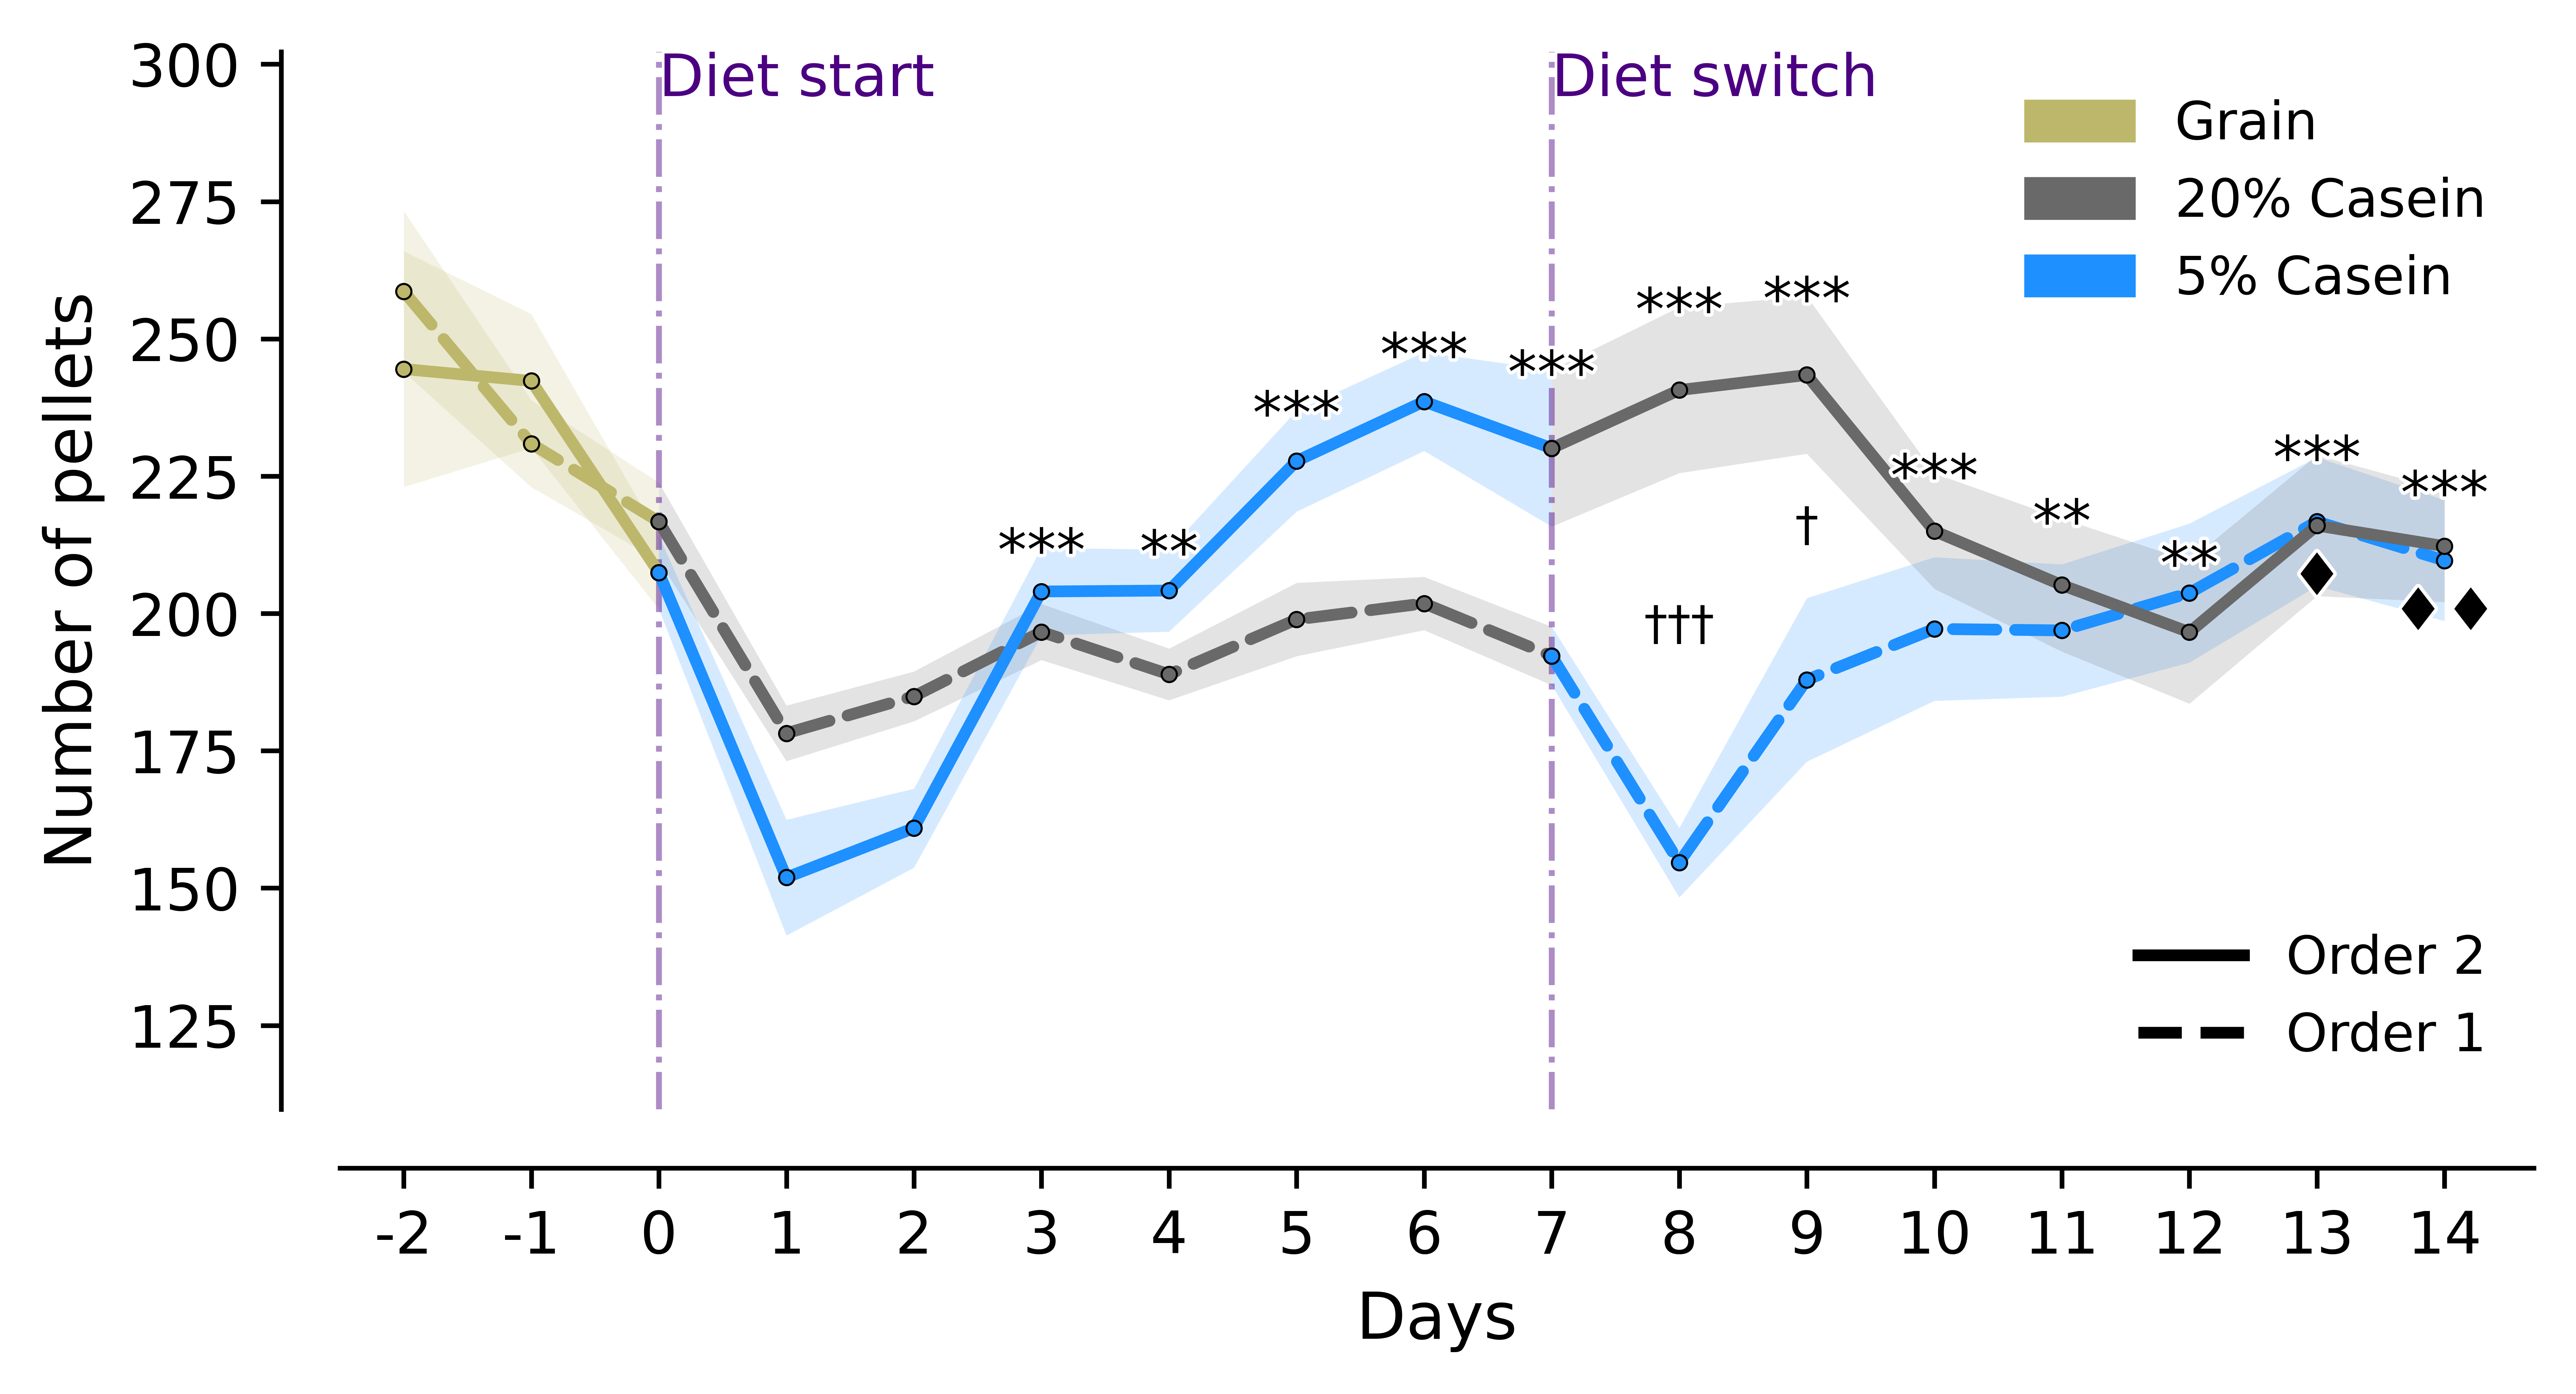

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import re, os
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe

def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try 3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    # anchor on mean or mean±SEM
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    # build a data+screen transform with vertical offset in points
    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])



file_path = '../results/PELLET_INTAKE/pellets_trend.csv'

# Posthoc CSVs 
spec_dir = '../results/PELLET_INTAKE/RE_DO'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars on O2
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers
# NR0 (Order 1) vs all Order 1 days (NR1–6, PR0–6) -> diamonds on O1
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')


meals_per_day_data = pd.read_csv(file_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = meals_per_day_data[meals_per_day_data["Order"] == 1]
order_1_data = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = meals_per_day_data[meals_per_day_data["Order"] == 2]
order_2_data = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

def mask_below_threshold(data, threshold=50):
    arr = np.array(data, dtype=float)
    return np.where(arr >= threshold, arr, np.nan)

threshold = 50
order_1_data = mask_below_threshold(order_1_data, threshold)
order_2_data = mask_below_threshold(order_2_data, threshold)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

o1_mean, o1_sem = mean_sem(order_1_data, axis=0)
o2_mean, o2_sem = mean_sem(order_2_data, axis=0)


x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

#
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

# For Order 1 (Grain -> NR -> PR)
o1_colors = (color_grain, color_nr, color_pr)
# For Order 2 (Grain -> PR -> NR)
o2_colors = (color_grain, color_pr, color_nr)

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# ===
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df):
    for c in df.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in df.columns:
            ccol = cand; break
    if ccol is None:
        ccol = df.columns[0]
    df['_contrast_str'] = df[ccol].astype(str)
    df['_p'] = df[pcol(df)].astype(float)
    return df

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

#===============
PR0_any_O2 = {}    # stars for PR0 (O2) vs PR1–6 & NR0–6 (O2)
O1_NR0_any = {}    # diamonds for NR0 (O1) vs NR1–6 & PR0–6 (O1)
DAG_PR     = {}    # daggers for O2:PRk vs O1:NRk (x=3..9)
DAG_NR     = {}    # daggers for O2:NRk vs O1:PRk (x=10..16)

# A) PR0 vs ALL in Order 2 -> stars on Order 2
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs all Order 1 days -> diamonds on Order 1
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
for df_src, bucket, phase in [
    (load_spec(spec_O2PRk_vs_O1NRk), DAG_PR, 'PR'),
    (load_spec(spec_O2NRk_vs_O1PRk), DAG_NR, 'NR'),
]:
    if df_src is None: 
        continue
    for _, row in df_src.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s:
            continue
        if phase=='PR' and phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            bucket[x_idx(2,'PR',dA)] = s
        elif phase=='PR' and phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            bucket[x_idx(2,'PR',dB)] = s
        if phase=='NR' and phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            bucket[x_idx(2,'NR',dA)] = s
        elif phase=='NR' and phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            bucket[x_idx(2,'NR',dB)] = s


fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers
ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Axis range & generous headroom (extra bottom room for diamonds)
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X-axis relabel: 0,1,2 -> -2,-1,0 ; 3..16 -> 1..14
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Number of pellets", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# Legends
Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                 loc='upper right', frameon=False, fontsize=9)

order_handles = [
    Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
]
leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
ax.add_artist(leg1)

# ======================== ANNOTATIONS ======================== ######################
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (above Order 2 line)
for xi, st in PR0_any_O2.items():
    if st:
        y2, y2s = y_at(2, xi)
        if np.isfinite(y2):
            annotate_near_line(ax, xi, y2, y2s, st, side='above', offset_pts=-6, fs=10, use_sem=True)

# Diamonds (below Order 1 line)
for xi, dm in O1_NR0_any.items():
    if dm:
        y1, y1s = y_at(1, xi)
        if np.isfinite(y1):
            annotate_near_line(ax, xi, y1, y1s, dm, side='below', offset_pts=-6, fs=10, use_sem=True)

# Daggers stay between lines (unchanged)
DRAW_CONNECTORS = False
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                    fontsize=8, color='black', zorder=7)


plt.tight_layout()
# fig = plt.gcf()
fig.savefig("../plots/Fig.2B.pdf", bbox_inches="tight")
# plt.show()


# bodyweight dynamics

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os
import re


file_path   = '../results/Bodyweight/BODYWEIGHT.csv'
posthoc_dir = '../results/Bodyweight/RE_DO_BODYWEIGHT'
df = pd.read_csv(file_path)

# Day columns
grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# ===help
def get_order_data(sex: str, order: int) -> np.ndarray:
    """Return (n_mice x 17) for given sex/order.
       Order 1: Grain->NR->PR ; Order 2: Grain->PR->NR."""
    sub = df[(df["Sex"] == sex) & (df["Order"] == order)]
    cols = grain_cols + (nr_cols + pr_cols if order == 1 else pr_cols + nr_cols)
    return sub[cols].to_numpy(dtype=float)

def mean_sem(a: np.ndarray, axis=0):
    if a.size == 0:
        return np.full(17, np.nan), np.full(17, np.nan)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

def mask_below_threshold(arr: np.ndarray, threshold=None):
    if threshold is None:
        return arr
    out = arr.astype(float, copy=True)
    out[out < threshold] = np.nan
    return out

# Point-offset annotation helper (hug text to line in *points*)
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above',
                       offset_pts=-6, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the curve with a fixed point offset.
      - side: 'above' or 'below'
      - offset_pts: distance in *points* (negative hugs closer; positive moves away)
      - use_sem: anchor on mean±SEM if True, otherwise on the mean
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=10,
        clip_on=False
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

# X indices and phase spans
x = np.arange(17)
x_grain = np.arange(0, 3)    # 0..2
x_mid   = np.arange(2, 10)   # 2..9  (G2 + week 1 of the first diet phase)
x_last  = np.arange(9, 17)   # 9..16 (last of week1 + week2)

# Colours & line styles
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein
o1_ls = "--"                # dashed
o2_ls = "-"                 # solid


def _find_p_col(cols):
    # normalise: keep only letters
    norm = {c: re.sub(r'[^a-z]', '', c.lower()) for c in cols}
    # common variants from R/emmeans/broom: 'p.value', 'p', 'p.adj', etc.
    wanted = {'p', 'pvalue', 'pval', 'padj', 'pvalueadj', 'prf', 'probgtf'}
    for c, k in norm.items():
        if k in wanted:
            return c
    # fallback to exact 'p.value' if present
    if 'p.value' in cols:
        return 'p.value'
    raise KeyError(f"No p-value column found; saw: {list(cols)}")

def p_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def p_to_diamonds(p):
    # If you prefer a single ◆ regardless of level, just: return '◆' if p < 0.05 else ''
    s = p_to_stars(p)
    return '◆' * len(s) if s else ''


# Parse one side like "PR3 Order2 SexM"
SIDE_RE = re.compile(r'^(NR|PR)\s*([0-9]+)\s+Order\s*([12])\s+Sex\s*([MF])$')

def parse_side(s: str):
    s = s.strip()
    m = SIDE_RE.match(s)
    if not m:
        raise ValueError(f"Could not parse side: {s}")
    phase = m.group(1)
    day   = int(m.group(2))
    order = int(m.group(3))
    sex   = m.group(4)
    return phase, day, order, sex

def split_contrast(label: str):
    if ' - ' in label:
        L, R = label.split(' - ', 1)
        return L.strip(), R.strip()
    return label, ""

# x-index mapping by (Order, phase, day)
def x_index(order: int, phase: str, day: int) -> int:
    # Absolute timeline on the plot
    # G: 0..2
    # First diet phase days 0..6 -> x 3..9
    # Second diet phase days 0..6 -> x 10..16
    if order == 1:
        if phase == 'NR': return 3 + day         # week 1
        if phase == 'PR': return 10 + day        # week 2
    elif order == 2:
        if phase == 'PR': return 3 + day         # week 1
        if phase == 'NR': return 10 + day        # week 2
    raise ValueError(f"Bad (order,phase,day): {(order, phase, day)}")

def load_sig_positions_for_sex(sex_label: str, alpha=0.05):
    """
    Return three dicts (x -> symbol):
      stars:    O2 PR0 vs all O2 days  -> '*'/'**'/'***'
      diamonds: O1 NR0 vs all O1 days  -> '◆','◆◆','◆◆◆'
      daggers:  between-order matched  -> '†' 
    """
    stars    = {}  # x -> '*/**/***'
    diamonds = {}  # x -> '◆/◆◆/◆◆◆'
    daggers  = set()

    # ---- Stars: O2 PR0 vs all O2 days ----
    f_stars = os.path.join(posthoc_dir, f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
    if os.path.exists(f_stars):
        ph = pd.read_csv(f_stars)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_stars(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            # find the non-PR0 side to place the mark
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'PR' and d == 0 and o == 2 and sx == sex_label):
                    if o == 2 and sx == sex_label:
                        xi = x_index(2, phs, d)
                        # keep the most significant if duplicate
                        stars[xi] = max(stars.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing stars file: {f_stars}")

    # ---- Diamonds: O1 NR0 vs all O1 days ----
    f_dia = os.path.join(posthoc_dir, f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
    if os.path.exists(f_dia):
        ph = pd.read_csv(f_dia)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_diamonds(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'NR' and d == 0 and o == 1 and sx == sex_label):
                    if o == 1 and sx == sex_label:
                        xi = x_index(1, phs, d)
                        diamonds[xi] = max(diamonds.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing diamonds file: {f_dia}")

    # -
    for fname in [
        os.path.join(posthoc_dir, f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv"),
        os.path.join(posthoc_dir, f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv"),
    ]:
        if os.path.exists(fname):
            ph = pd.read_csv(fname)
            pcol = _find_p_col(ph.columns)
            if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
                ph['contrast'] = ph['contrast_pretty']
            for _, row in ph.iterrows():
                p = row[pcol]
                if pd.isna(p) or p >= alpha:
                    continue
                L, R = split_contrast(str(row['contrast']))
                for side in (L, R):
                    try:
                        phs, d, o, sx = parse_side(side)
                    except Exception:
                        continue
                    if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
                        daggers.add(x_index(o, phs, d))
                        break
        else:
            print(f"[WARN] Missing daggers file: {fname}")

    return stars, diamonds, daggers


def plot_bodyweight_with_stats(
    sex_label: str,
    data_o1: np.ndarray,
    data_o2: np.ndarray,
    save_path: str,
    title: str = "",
    show_legends: bool = True,
    ylabel: str = "Bodyweight (g)",
    threshold: float | None = None,
    alpha: float = 0.05
):
    # Optional masking
    data_o1 = mask_below_threshold(data_o1, threshold)
    data_o2 = mask_below_threshold(data_o2, threshold)

    # Means & SEM
    o1_mean, o1_sem = mean_sem(data_o1, axis=0)
    o2_mean, o2_sem = mean_sem(data_o2, axis=0)

    # Colour order per group
    o1_colors = (color_grain, color_nr, color_pr)  # O1: Grain->NR->PR
    o2_colors = (color_grain, color_pr, color_nr)  # O2: Grain->PR->NR

    fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

    # ----- Order 1 line -----
    ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
    ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                    color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
    ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                    color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
    ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                    color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # ----- Order 2 line -----
    ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
    ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                    color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
    ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                    color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
    ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                    color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

  
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

    # ---- Axes format ----
    ax.set_xlim(-0.5, 16.7)
    ax.set_xticks(np.arange(17))
    ax.set_xticklabels([str(i - 2) for i in range(17)])  # -2, -1, 0, 1..14
    ax.set_xlabel("Days", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.spines['bottom'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    # ---
    y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
    y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
    if not np.isfinite(y_top) or not np.isfinite(y_bot):
        y_top, y_bot = 1.0, 0.0
    yr = max(y_top - y_bot, 1.0)
    ax.set_ylim(y_bot - 0.24*yr, y_top + 0.22*yr)  # generous top & bottom margins

    # ---- Diet labels ON TOP OF the vertical lines (matches pellets plot) ----
    label_y = y_bot + 1.22*yr
    ax.text(2, label_y, "Diet start",  ha='left', va='top', fontsize=10, color="indigo", clip_on=False)
    ax.text(9, label_y, "Diet switch", ha='left', va='top', fontsize=10, color="indigo", clip_on=False)

    # --
    stars, diamonds, daggers = load_sig_positions_for_sex(sex_label, alpha=alpha)
    STAR_OFFSET_PTS, DIAMOND_OFFSET_PTS = -7, -7

    # * / ** / *** above Order 2
    for xi in sorted(stars):
        sym = stars[xi]
        if 0 <= xi < 17 and np.isfinite(o2_mean[xi]) and sym:
            annotate_near_line(ax, xi, o2_mean[xi], o2_sem[xi],
                            text=sym, side='above',
                            offset_pts=STAR_OFFSET_PTS, fs=10, use_sem=True)

    # 
    for xi in sorted(diamonds):
        sym = diamonds[xi]
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and sym:
            annotate_near_line(ax, xi, o1_mean[xi], o1_sem[xi],
                            text=sym, side='above',
                            offset_pts=DIAMOND_OFFSET_PTS, fs=10, use_sem=True)

    # † stays single, centred between lines
    for xi in sorted(daggers):
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and np.isfinite(o2_mean[xi]):
            ymid = 0.5 * (min(o1_mean[xi], o2_mean[xi]) + max(o1_mean[xi], o2_mean[xi]))
            t = ax.text(xi, ymid, '†', ha='center', va='center', fontsize=10, zorder=10)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])


    # Legends
    if show_legends:
        Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
        NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
        PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
        leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                         loc='upper right', frameon=False, fontsize=9)
        order_handles = [
            Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
            Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
        ]
        leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
        ax.add_artist(leg1)

    if title:
        ax.set_title(title, loc="left", pad=6, fontsize=10)

    plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


# =========================== Build + Save 
male_o1   = get_order_data("M", 1)
male_o2   = get_order_data("M", 2)
female_o1 = get_order_data("F", 1)
female_o2 = get_order_data("F", 2)

# Males
plot_bodyweight_with_stats(
    sex_label="M",
    data_o1=male_o1, data_o2=male_o2,
    save_path="../plots/Fig.3.B.pdf",
    title="", show_legends=True
)

# Females
plot_bodyweight_with_stats(
    sex_label="F",
    data_o1=female_o1, data_o2=female_o2,
    save_path="../plots/Fig.3.D.pdf",
    title="", show_legends=False
)


# number of meals

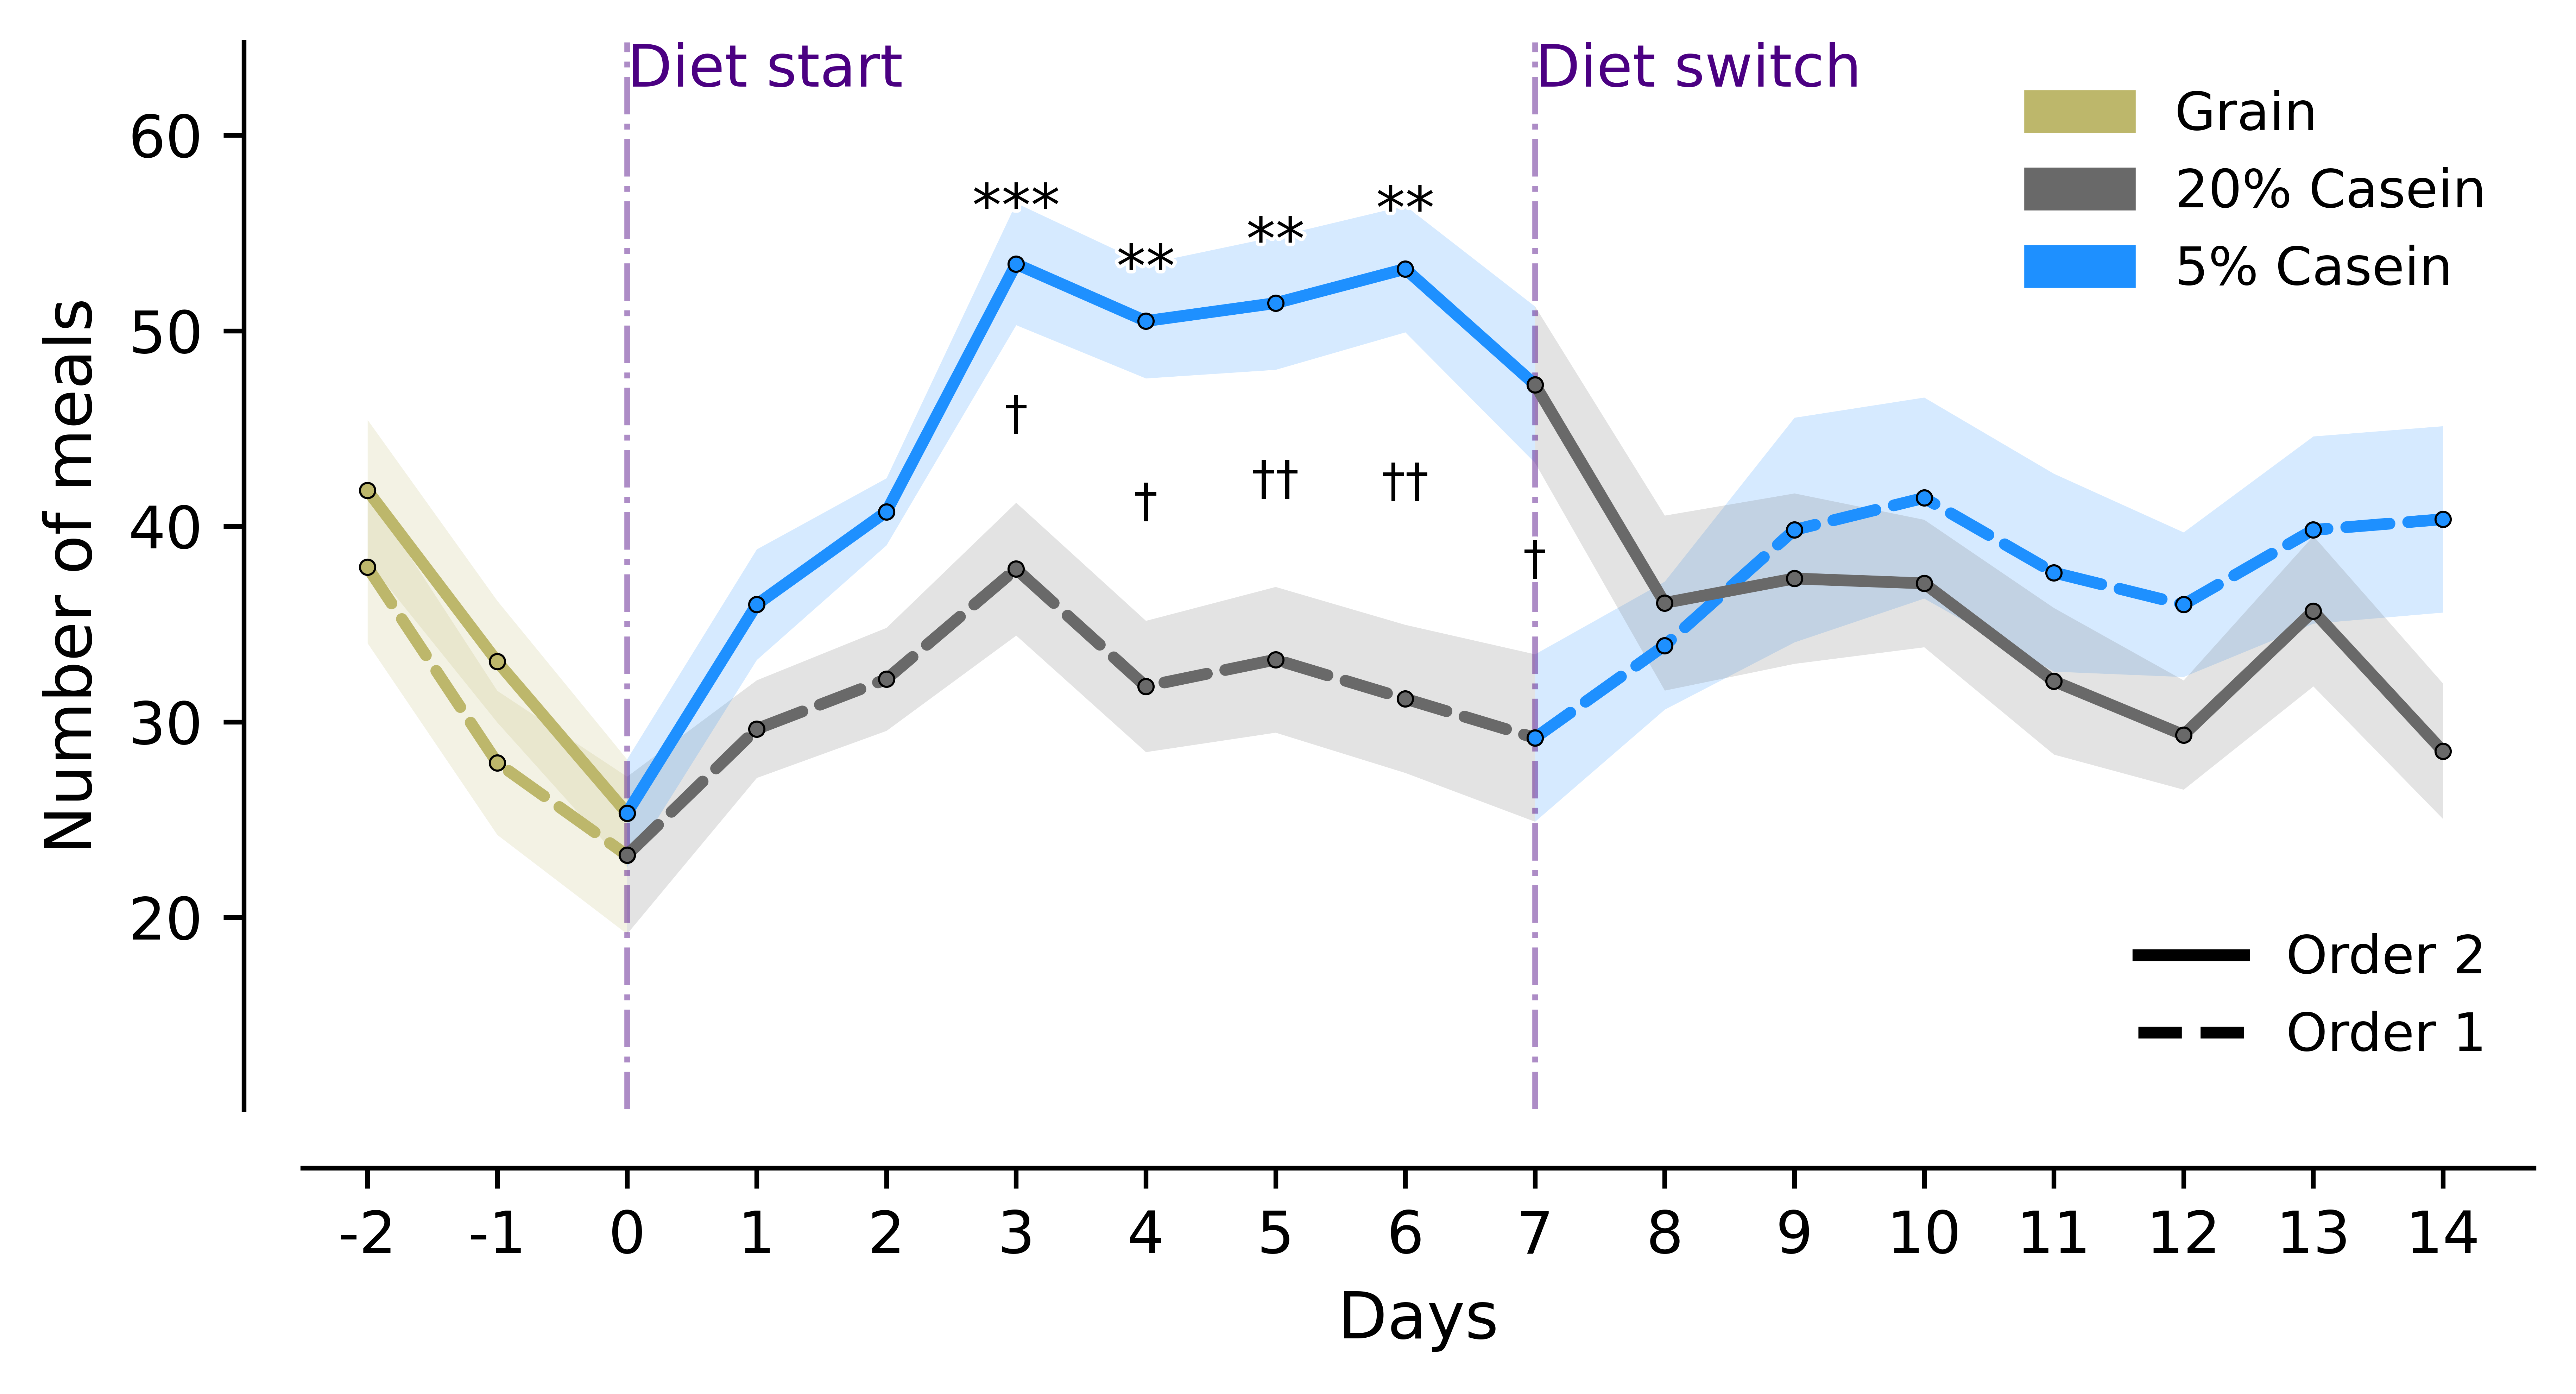

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re


trend_path = '../results/MEAL/meals_per_day_trend.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/MEAL/RE_DO_MEAL_NUMBER'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)


RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.5B.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'below'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge


def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

#
df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# ====================
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# ==
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid


PR0_any_O2 = {}   # stars
O1_NR0_any = {}   # diamonds
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1 -> diamonds
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# ============
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Number of meals", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# Diet legend
Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                 loc='upper right', frameon=False, fontsize=9)

# Order legend
order_handles = [
    Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
]
leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
ax.add_artist(leg1)

# ===========
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Daggers (cross-order) BETWEEN lines 
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()


# meal frequency 

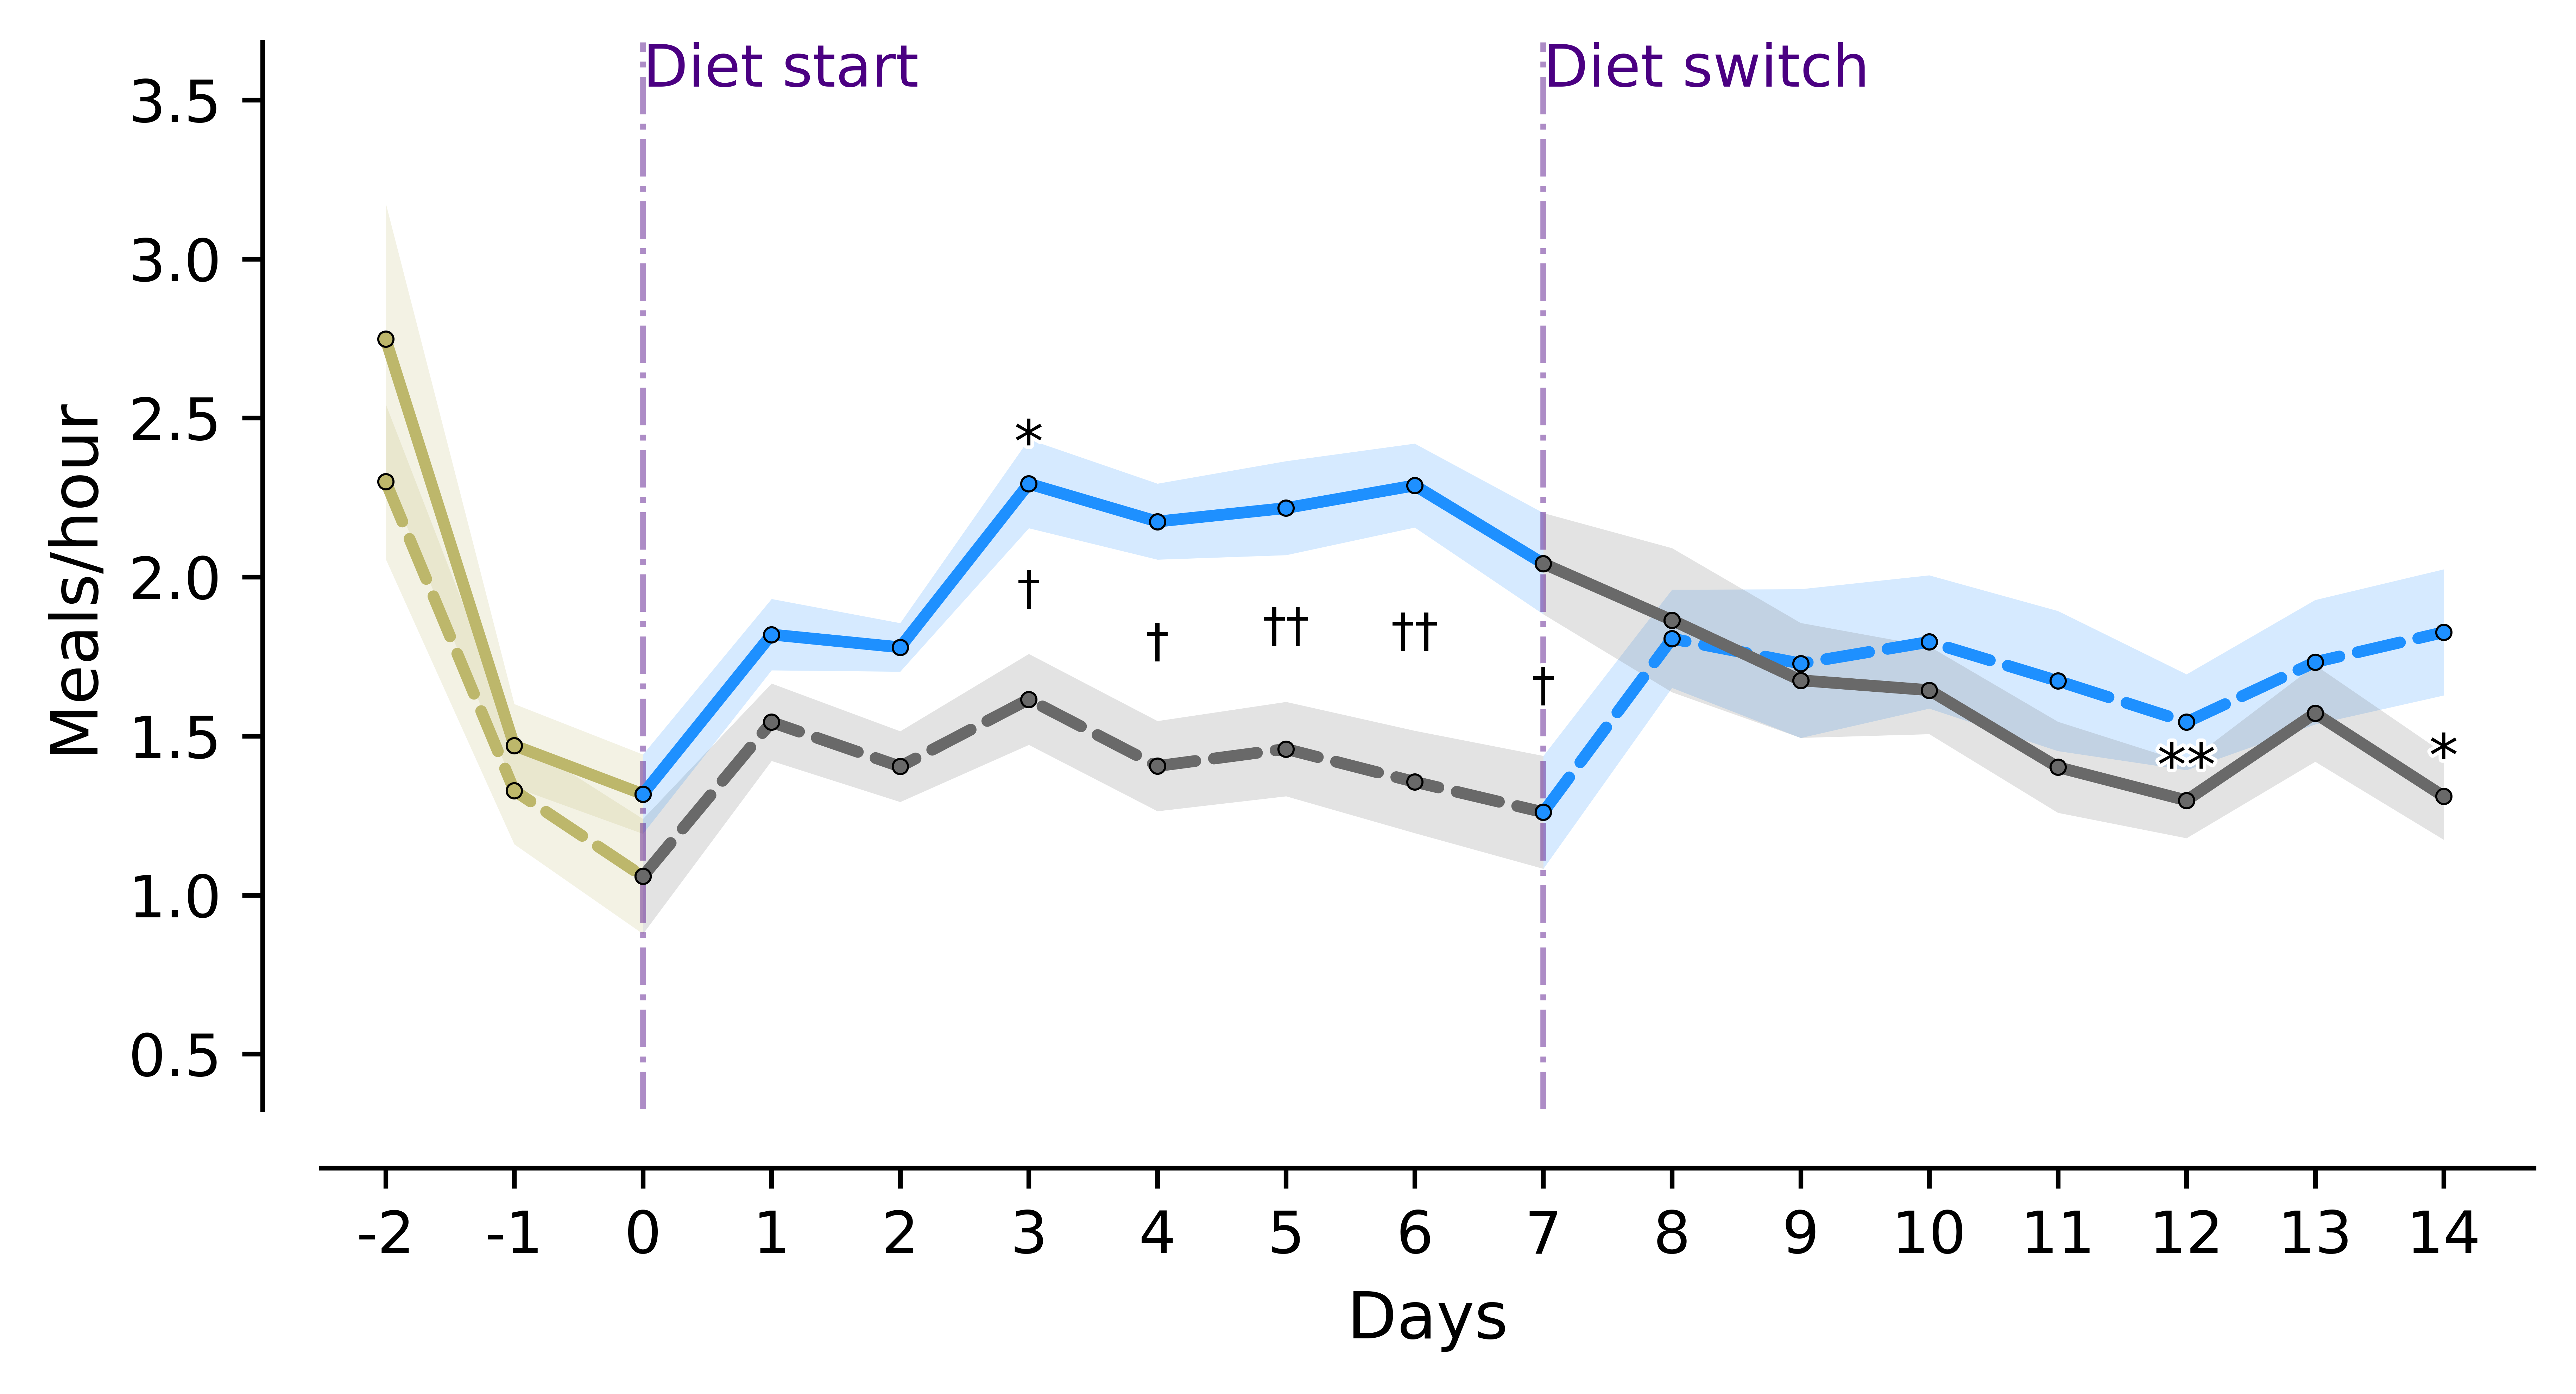

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re

trend_path = '../results/MEAL/meal_freq_per_day/meal_freq_realigned_FINAL.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/MEAL/meal_freq_per_day/RE_DO_MEALFREQUENCY'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)

# 
RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.5D.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'below'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge

# ======================== HELPERS 
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

# =============
df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# ==========================
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# color======
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

# ================
PR0_any_O2 = {}   # stars: PR0 (O2) vs all O2 (PR1–6, NR0–6) -> above O2
O1_NR0_any = {}   # diamonds: NR0 (O1) vs all O1 (NR1–6, PR0–6) -> below O1
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# =====================
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Meals/hour", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# # Diet legend
# Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
# NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
# PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
# leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
#                  loc='upper right', frameon=False, fontsize=9)

# # Order legend
# order_handles = [
#     Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
#     Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
# ]
# leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
# ax.add_artist(leg1)

# ======================== ANNOTATIONS ===
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

#
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()


# meal size

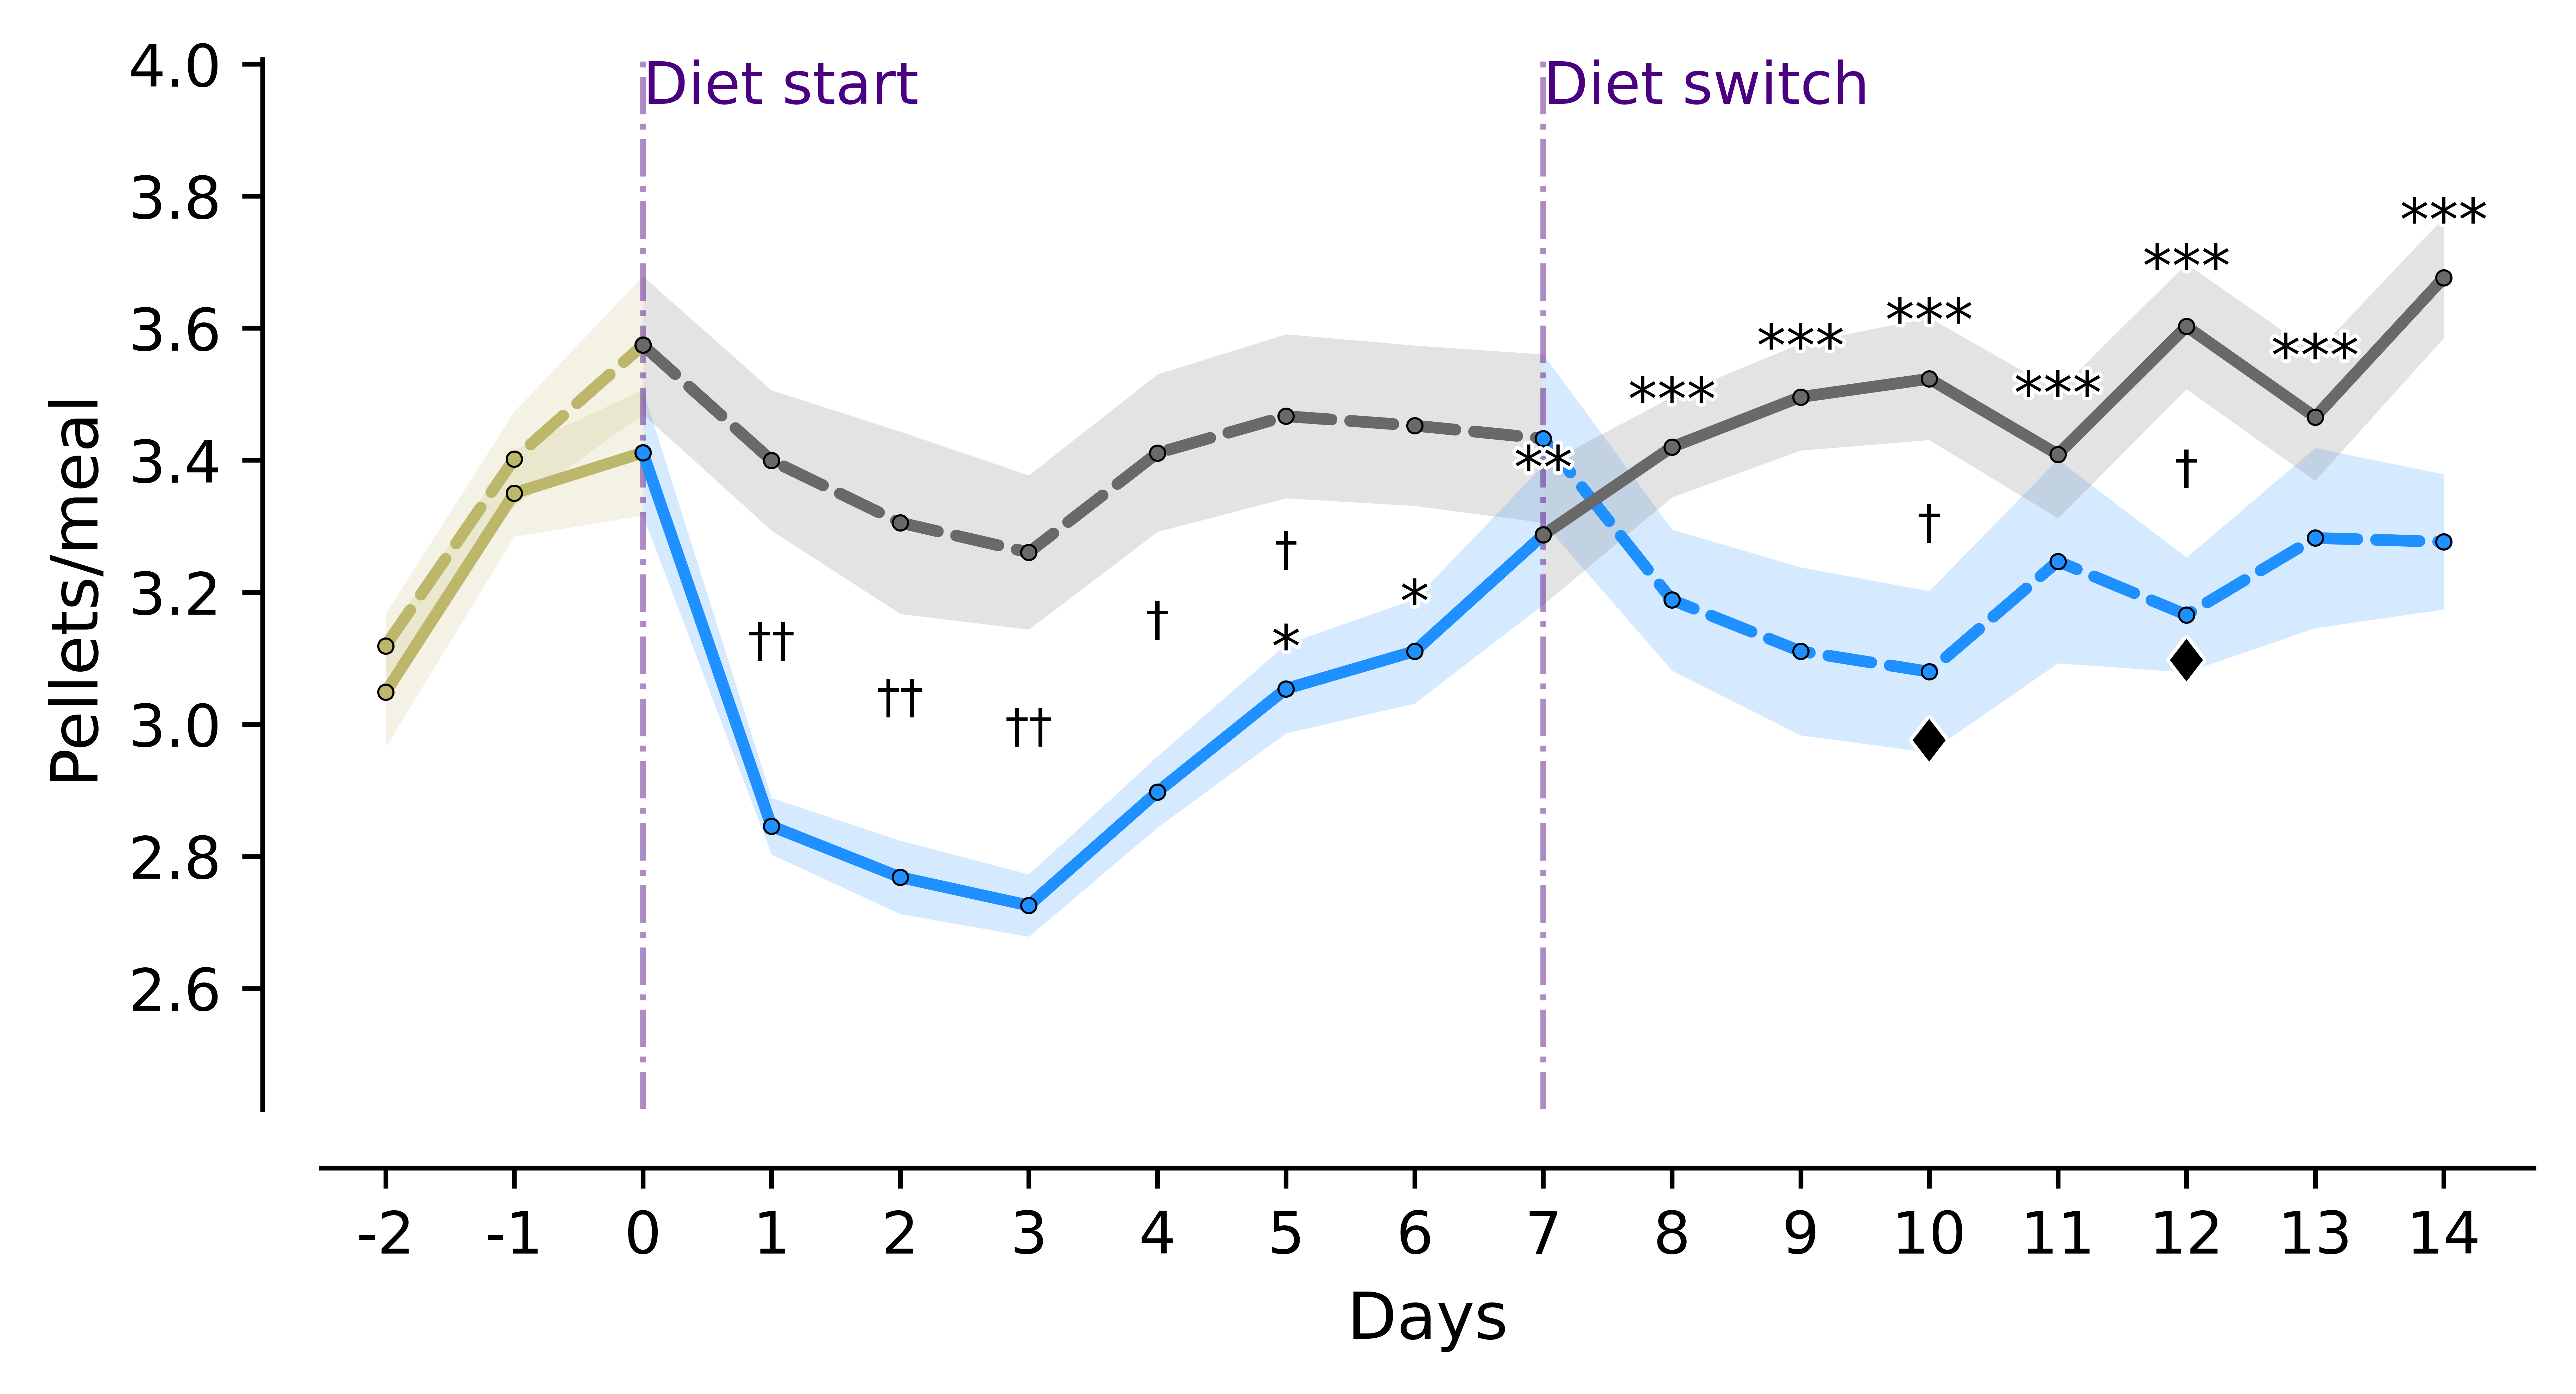

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re

# ================
trend_path = '../results/MEAL/meal_size_per_day/meal_size_realigned_FINAL.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/MEAL/meal_size_per_day/RE_DO_MEAL_SIZE'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)

# =====================
RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.5F.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'below'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge


def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''


df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# ======================== X-AXIS SEGMENTS ========================
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# ======================== COLOURS & LINES ========================
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

# ======================== BUILD ANNOTATION MAPS ========================
PR0_any_O2 = {}   # stars: PR0 (O2) vs all O2 (PR1–6, NR0–6) -> above O2
O1_NR0_any = {}   # diamonds: NR0 (O1) vs all O1 (NR1–6, PR0–6) -> below O1
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1 -> diamonds
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# === PLOT =
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Pellets/meal", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# # Diet legend
# Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
# NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
# PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
# leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
#                  loc='lower right', frameon=False, fontsize=9)

# # Order legend
# order_handles = [
#     Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
#     Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
# ]
# leg2 = ax.legend(handles=order_handles, loc='upper right', frameon=False, fontsize=9)
# ax.add_artist(leg1)


def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )


for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()


# number of snacks

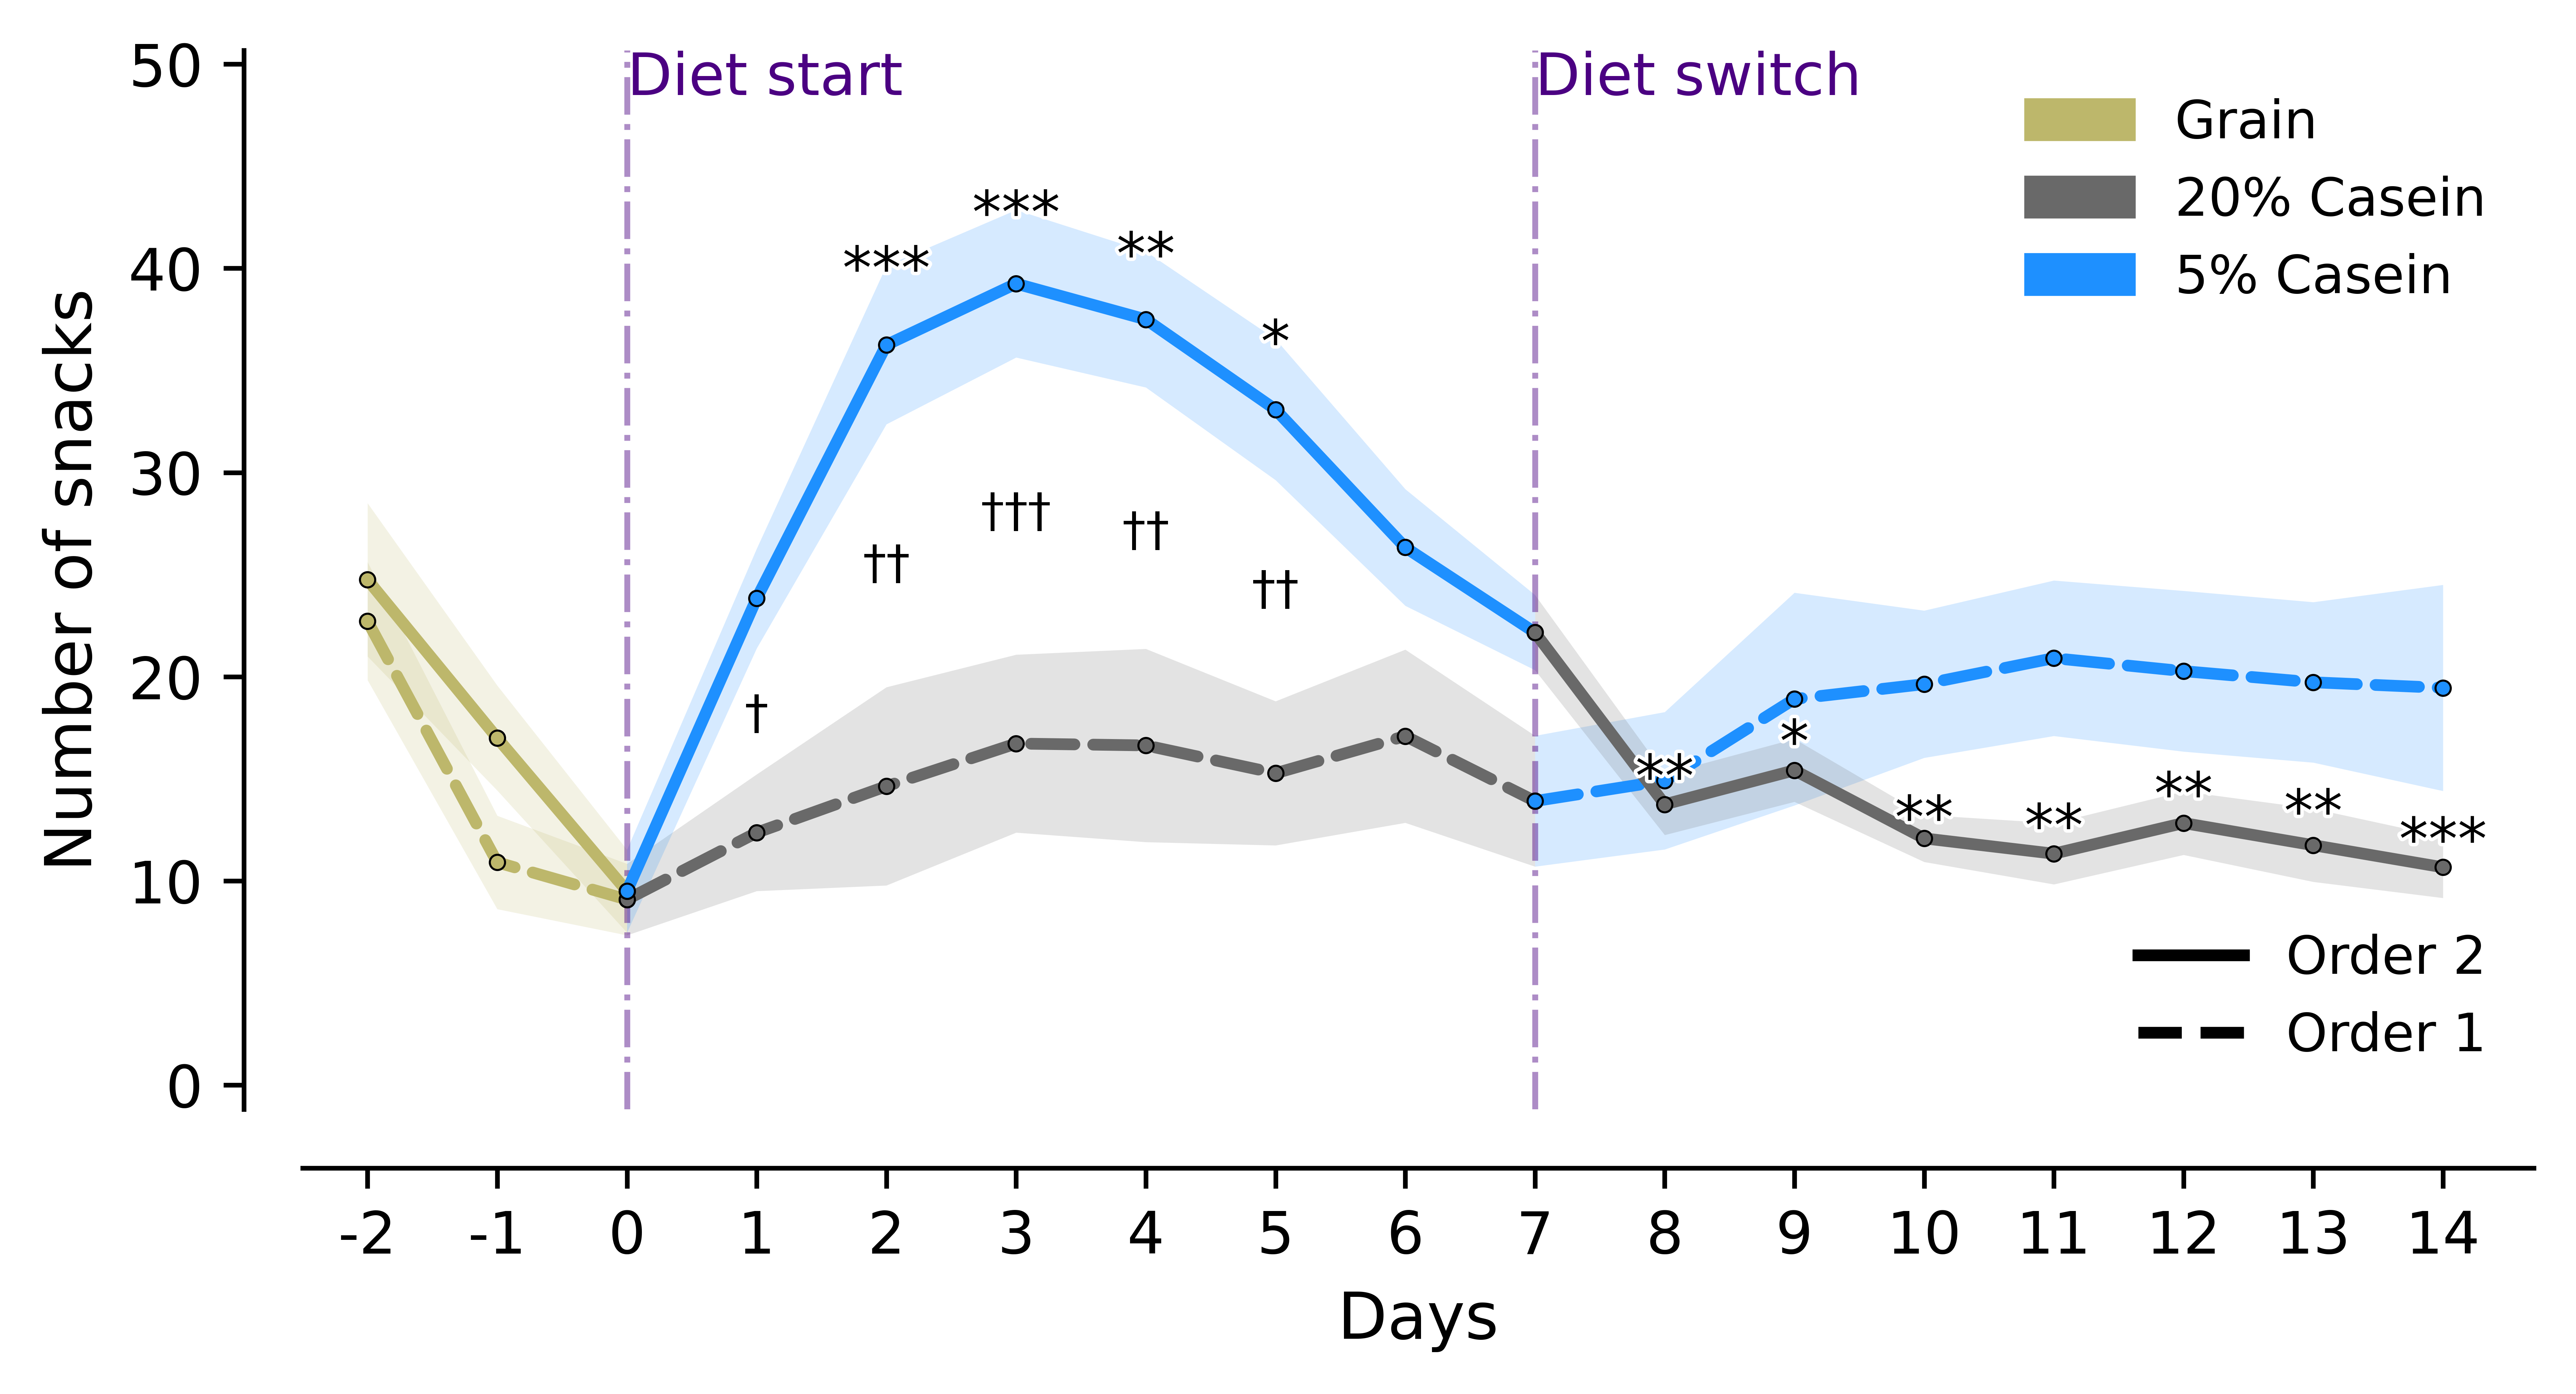

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re


trend_path = '../results/SNACK/snacks_per_day_trend.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/SNACK/RE_DO'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)


RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.6B.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'below'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge


def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

# =========
df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# =====================AXIS SEGMENTS =============
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# COLOURS & LINES ================
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

#  BUILD ANNOTATION MAPS =================
PR0_any_O2 = {}   # stars: PR0 (O2) vs all O2 (PR1–6, NR0–6) -> above O2
O1_NR0_any = {}   # diamonds: NR0 (O1) vs all O1 (NR1–6, PR0–6) -> below O1
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1 -> diamonds
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# ====
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Number of snacks", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# Diet legend
Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                 loc='upper right', frameon=False, fontsize=9)

# Order legend
order_handles = [
    Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
]
leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
ax.add_artist(leg1)

# ==============================
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Daggers (cross-order) BETWEEN lines (unchanged placement)
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()


# snack frequency 

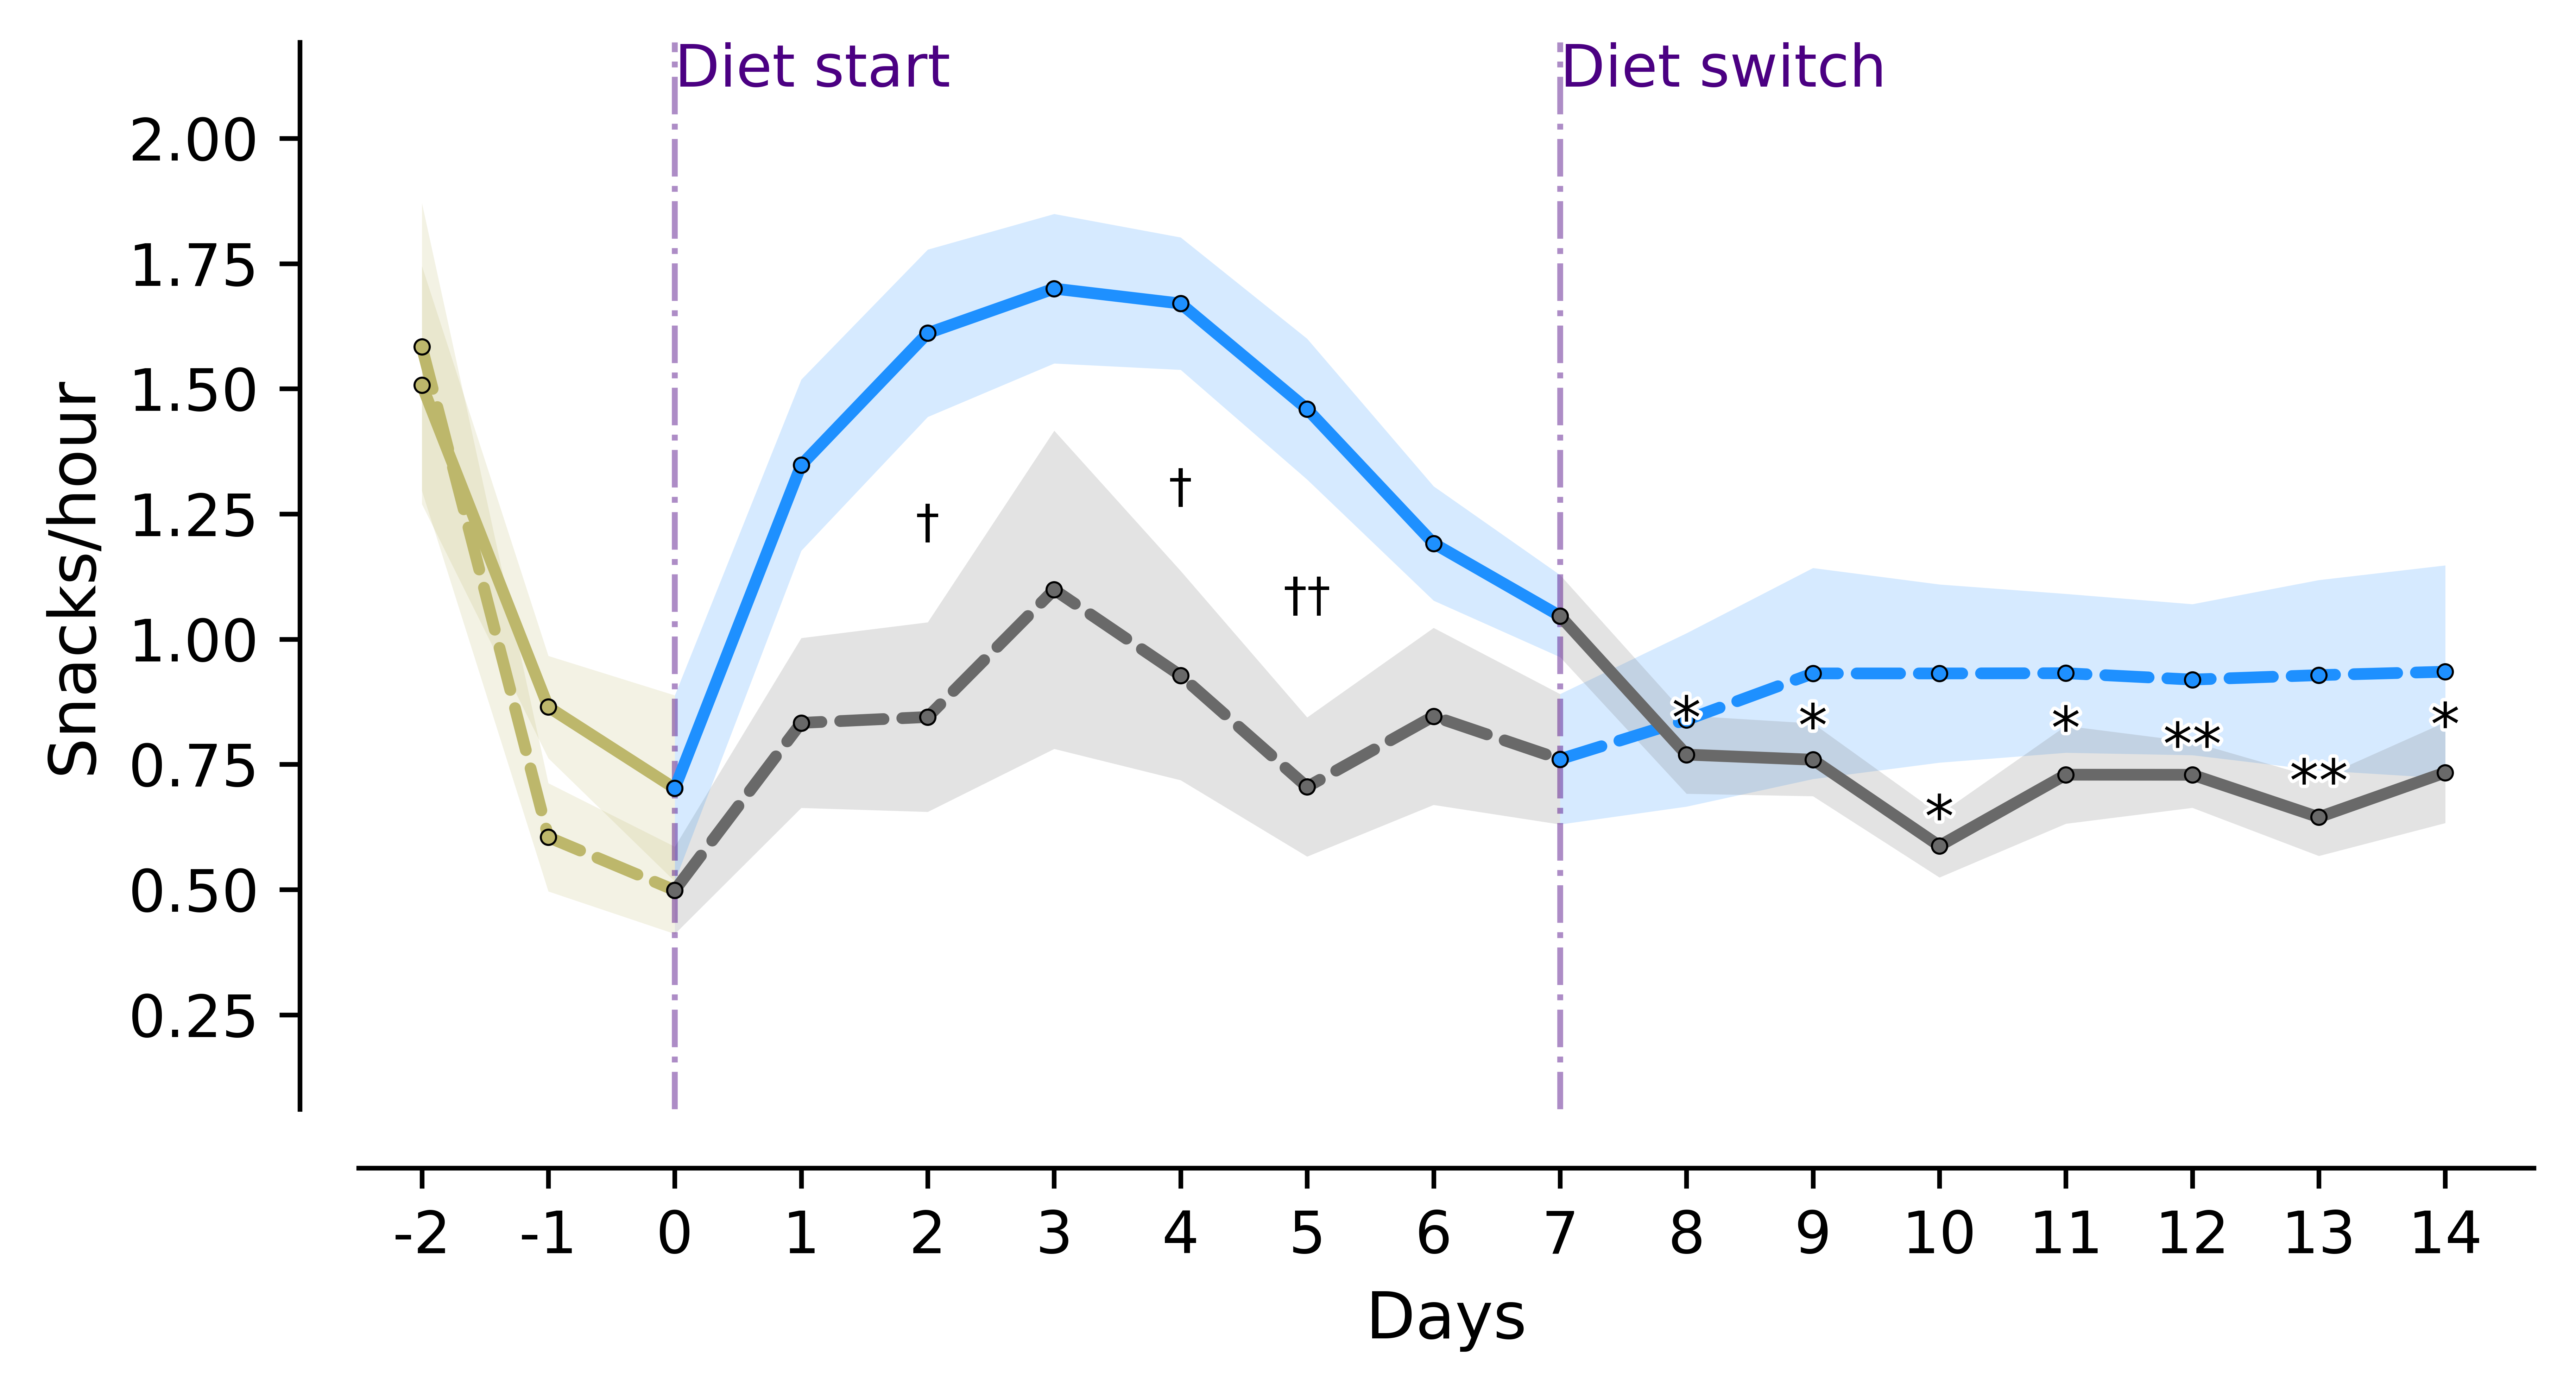

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re

# ===============USER PATHS ======
trend_path = '../results/SNACK/snack_freq_per_day/snack_freq_realigned_FINAL.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/SNACK/snack_freq_per_day/RE_DO'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)


RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.6D.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'below'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge

# ============== HELPERS =====
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

# ======================== LOAD MEANS ========================
df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# ======================== X-AXIS SEGMENTS ========================
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# ======================== COLOURS & LINES ========================
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

# ======================== BUILD ANNOTATION MAPS ========================
PR0_any_O2 = {}   # stars: PR0 (O2) vs all O2 (PR1–6, NR0–6) -> above O2
O1_NR0_any = {}   # diamonds: NR0 (O1) vs all O1 (NR1–6, PR0–6) -> below O1
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1 -> diamonds
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# ======================== PLOT ========================
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Snacks/hour", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# # Diet legend
# Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
# NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
# PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
# leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
#                  loc='upper right', frameon=False, fontsize=9)

# # Order legend
# order_handles = [
#     Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
#     Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
# ]
# leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
# ax.add_artist(leg1)

# ======================== ANNOTATIONS ========================
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Daggers (cross-order) BETWEEN lines (unchanged placement)
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()


# number of feasts

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os
import re

# =========================== Paths & data ===========================
file_path   = '../results/FEAST/mega_meals_per_day_trend.csv'
posthoc_dir = '../results/FEAST/FEAST_NUMBER_RE_DO'
df = pd.read_csv(file_path)

# Day columns
grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# =========================== Helpers ===============================
def get_order_data(sex: str, order: int) -> np.ndarray:
    """Return (n_mice x 17) for given sex/order.
       Order 1: Grain->NR->PR ; Order 2: Grain->PR->NR."""
    sub = df[(df["Sex"] == sex) & (df["Order"] == order)]
    cols = grain_cols + (nr_cols + pr_cols if order == 1 else pr_cols + nr_cols)
    return sub[cols].to_numpy(dtype=float)

def mean_sem(a: np.ndarray, axis=0):
    if a.size == 0:
        return np.full(17, np.nan), np.full(17, np.nan)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

def mask_below_threshold(arr: np.ndarray, threshold=None):
    if threshold is None:
        return arr
    out = arr.astype(float, copy=True)
    out[out < threshold] = np.nan
    return out

# Point-offset annotation helper (hug text to line in *points*)
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above',
                       offset_pts=-6, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the curve with a fixed point offset.
      - side: 'above' or 'below'
      - offset_pts: distance in *points* (negative hugs closer; positive moves away)
      - use_sem: anchor on mean±SEM if True, otherwise on the mean
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=10,
        clip_on=False
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

# X indices and phase spans
x = np.arange(17)
x_grain = np.arange(0, 3)    # 0..2
x_mid   = np.arange(2, 10)   # 2..9  (G2 + week 1 of the first diet phase)
x_last  = np.arange(9, 17)   # 9..16 (last of week1 + week2)

# Colours & line styles
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein
o1_ls = "--"                # dashed
o2_ls = "-"                 # solid


def _find_p_col(cols):
    # normalise: keep only letters
    norm = {c: re.sub(r'[^a-z]', '', c.lower()) for c in cols}
    # common variants from R/emmeans/broom: 'p.value', 'p', 'p.adj', etc.
    wanted = {'p', 'pvalue', 'pval', 'padj', 'pvalueadj', 'prf', 'probgtf'}
    for c, k in norm.items():
        if k in wanted:
            return c
    # fallback to exact 'p.value' if present
    if 'p.value' in cols:
        return 'p.value'
    raise KeyError(f"No p-value column found; saw: {list(cols)}")

def p_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def p_to_diamonds(p):
    # If you prefer a single ◆ regardless of level, just: return '◆' if p < 0.05 else ''
    s = p_to_stars(p)
    return '◆' * len(s) if s else ''


# Parse one side like "PR3 Order2 SexM"
SIDE_RE = re.compile(r'^(NR|PR)\s*([0-9]+)\s+Order\s*([12])\s+Sex\s*([MF])$')

def parse_side(s: str):
    s = s.strip()
    m = SIDE_RE.match(s)
    if not m:
        raise ValueError(f"Could not parse side: {s}")
    phase = m.group(1)
    day   = int(m.group(2))
    order = int(m.group(3))
    sex   = m.group(4)
    return phase, day, order, sex

def split_contrast(label: str):
    if ' - ' in label:
        L, R = label.split(' - ', 1)
        return L.strip(), R.strip()
    return label, ""

# x-index mapping by (Order, phase, day)
def x_index(order: int, phase: str, day: int) -> int:
    # Absolute timeline on the plot
    # G: 0..2
    # First diet phase days 0..6 -> x 3..9
    # Second diet phase days 0..6 -> x 10..16
    if order == 1:
        if phase == 'NR': return 3 + day         # week 1
        if phase == 'PR': return 10 + day        # week 2
    elif order == 2:
        if phase == 'PR': return 3 + day         # week 1
        if phase == 'NR': return 10 + day        # week 2
    raise ValueError(f"Bad (order,phase,day): {(order, phase, day)}")

def load_sig_positions_for_sex(sex_label: str, alpha=0.05):
    """
    Return three dicts (x -> symbol):
      stars:    O2 PR0 vs all O2 days  -> '*'/'**'/'***'
      diamonds: O1 NR0 vs all O1 days  -> '◆','◆◆','◆◆◆'
      daggers:  between-order matched  -> '†' (kept as single)
    """
    stars    = {}  # x -> '*/**/***'
    diamonds = {}  # x -> '◆/◆◆/◆◆◆'
    daggers  = set()

    # ---- Stars: O2 PR0 vs all O2 days ----
    f_stars = os.path.join(posthoc_dir, f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
    if os.path.exists(f_stars):
        ph = pd.read_csv(f_stars)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_stars(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            # find the non-PR0 side to place the mark
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'PR' and d == 0 and o == 2 and sx == sex_label):
                    if o == 2 and sx == sex_label:
                        xi = x_index(2, phs, d)
                        # keep the most significant if duplicate
                        stars[xi] = max(stars.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing stars file: {f_stars}")

    # ---- Diamonds: O1 NR0 vs all O1 days ----
    f_dia = os.path.join(posthoc_dir, f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
    if os.path.exists(f_dia):
        ph = pd.read_csv(f_dia)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_diamonds(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'NR' and d == 0 and o == 1 and sx == sex_label):
                    if o == 1 and sx == sex_label:
                        xi = x_index(1, phs, d)
                        diamonds[xi] = max(diamonds.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing diamonds file: {f_dia}")

    # ---- Daggers: keep 1× dagger between lines (no level encoding) ----
    for fname in [
        os.path.join(posthoc_dir, f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv"),
        os.path.join(posthoc_dir, f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv"),
    ]:
        if os.path.exists(fname):
            ph = pd.read_csv(fname)
            pcol = _find_p_col(ph.columns)
            if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
                ph['contrast'] = ph['contrast_pretty']
            for _, row in ph.iterrows():
                p = row[pcol]
                if pd.isna(p) or p >= alpha:
                    continue
                L, R = split_contrast(str(row['contrast']))
                for side in (L, R):
                    try:
                        phs, d, o, sx = parse_side(side)
                    except Exception:
                        continue
                    if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
                        daggers.add(x_index(o, phs, d))
                        break
        else:
            print(f"[WARN] Missing daggers file: {fname}")

    return stars, diamonds, daggers


def plot_bodyweight_with_stats(
    sex_label: str,
    data_o1: np.ndarray,
    data_o2: np.ndarray,
    save_path: str,
    title: str = "",
    show_legends: bool = True,
    ylabel: str = "Number of feasts",
    threshold: float | None = None,
    alpha: float = 0.05
):
    # Optional masking
    data_o1 = mask_below_threshold(data_o1, threshold)
    data_o2 = mask_below_threshold(data_o2, threshold)

    # Means & SEM
    o1_mean, o1_sem = mean_sem(data_o1, axis=0)
    o2_mean, o2_sem = mean_sem(data_o2, axis=0)

    # Colour order per group
    o1_colors = (color_grain, color_nr, color_pr)  # O1: Grain->NR->PR
    o2_colors = (color_grain, color_pr, color_nr)  # O2: Grain->PR->NR

    fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

    # ----- Order 1 line -----
    ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
    ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                    color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
    ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                    color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
    ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                    color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # ----- Order 2 line -----
    ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
    ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                    color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
    ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                    color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
    ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                    color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # Phase dividers (same as pellets plot)
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

    # ---- Axes format ----
    ax.set_xlim(-0.5, 16.7)
    ax.set_xticks(np.arange(17))
    ax.set_xticklabels([str(i - 2) for i in range(17)])  # -2, -1, 0, 1..14
    ax.set_xlabel("Days", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.spines['bottom'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    # ---- Range + headroom (so labels fit above the lines) ----
    y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
    y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
    if not np.isfinite(y_top) or not np.isfinite(y_bot):
        y_top, y_bot = 1.0, 0.0
    yr = max(y_top - y_bot, 1.0)
    ax.set_ylim(y_bot - 0.24*yr, y_top + 0.22*yr)  # generous top & bottom margins

    # ---- Diet labels ON TOP OF the vertical lines (matches pellets plot) ----
    label_y = y_bot + 1.22*yr
    ax.text(2, label_y, "Diet start",  ha='left', va='top', fontsize=10, color="indigo", clip_on=False)
    ax.text(9, label_y, "Diet switch", ha='left', va='top', fontsize=10, color="indigo", clip_on=False)

    # ------- Significance (same behaviour as your current code) -------
    stars, diamonds, daggers = load_sig_positions_for_sex(sex_label, alpha=alpha)
    STAR_OFFSET_PTS, DIAMOND_OFFSET_PTS = -7, -7

    # * / ** / *** above Order 2
    for xi in sorted(stars):
        sym = stars[xi]
        if 0 <= xi < 17 and np.isfinite(o2_mean[xi]) and sym:
            annotate_near_line(ax, xi, o2_mean[xi], o2_sem[xi],
                            text=sym, side='above',
                            offset_pts=STAR_OFFSET_PTS, fs=10, use_sem=True)

    # ◆ / ◆◆ / ◆◆◆ above Order 1  (change p_to_diamonds if you prefer single ◆)
    for xi in sorted(diamonds):
        sym = diamonds[xi]
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and sym:
            annotate_near_line(ax, xi, o1_mean[xi], o1_sem[xi],
                            text=sym, side='above',
                            offset_pts=DIAMOND_OFFSET_PTS, fs=10, use_sem=True)

    # † stays single, centred between lines
    for xi in sorted(daggers):
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and np.isfinite(o2_mean[xi]):
            ymid = 0.5 * (min(o1_mean[xi], o2_mean[xi]) + max(o1_mean[xi], o2_mean[xi]))
            t = ax.text(xi, ymid, '†', ha='center', va='center', fontsize=10, zorder=10)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])


    # Legends
    if show_legends:
        Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
        NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
        PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
        leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                         loc='upper right', frameon=False, fontsize=9)
        order_handles = [
            Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
            Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
        ]
        leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
        ax.add_artist(leg1)

    if title:
        ax.set_title(title, loc="left", pad=6, fontsize=10)

    plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


# =========================== Build + Save ==========================
male_o1   = get_order_data("M", 1)
male_o2   = get_order_data("M", 2)
female_o1 = get_order_data("F", 1)
female_o2 = get_order_data("F", 2)

# Males
plot_bodyweight_with_stats(
    sex_label="M",
    data_o1=male_o1, data_o2=male_o2,
    save_path="../plots/Fig.7B.pdf",
    title="", show_legends=True
)

# Females
plot_bodyweight_with_stats(
    sex_label="F",
    data_o1=female_o1, data_o2=female_o2,
    save_path="../plots/Fig.8B.pdf",
    title="", show_legends=True
)


# feast size

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os
import re


file_path   = '../results/FEAST/feast_size_per_day/mega_meal_size_realigned_FINAL.csv'
posthoc_dir = '../results/FEAST/feast_size_per_day/FEAST_SIZE_RE_DO'
df = pd.read_csv(file_path)

# Day columns
grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]


def get_order_data(sex: str, order: int) -> np.ndarray:
    """Return (n_mice x 17) for given sex/order.
       Order 1: Grain->NR->PR ; Order 2: Grain->PR->NR."""
    sub = df[(df["Sex"] == sex) & (df["Order"] == order)]
    cols = grain_cols + (nr_cols + pr_cols if order == 1 else pr_cols + nr_cols)
    return sub[cols].to_numpy(dtype=float)

def mean_sem(a: np.ndarray, axis=0):
    if a.size == 0:
        return np.full(17, np.nan), np.full(17, np.nan)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

def mask_below_threshold(arr: np.ndarray, threshold=None):
    if threshold is None:
        return arr
    out = arr.astype(float, copy=True)
    out[out < threshold] = np.nan
    return out

# Point-offset annotation helper (hug text to line in *points*)
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above',
                       offset_pts=-6, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the curve with a fixed point offset.
      - side: 'above' or 'below'
      - offset_pts: distance in *points* (negative hugs closer; positive moves away)
      - use_sem: anchor on mean±SEM if True, otherwise on the mean
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=10,
        clip_on=False
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

# X indices and phase spans
x = np.arange(17)
x_grain = np.arange(0, 3)    # 0..2
x_mid   = np.arange(2, 10)   # 2..9  (G2 + week 1 of the first diet phase)
x_last  = np.arange(9, 17)   # 9..16 (last of week1 + week2)

# Colours & line styles
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein
o1_ls = "--"                # dashed
o2_ls = "-"                 # solid

# the working version of symbol overlay code
def _find_p_col(cols):
    # normalise: keep only letters
    norm = {c: re.sub(r'[^a-z]', '', c.lower()) for c in cols}
    # common variants from R/emmeans/broom: 'p.value', 'p', 'p.adj', etc.
    wanted = {'p', 'pvalue', 'pval', 'padj', 'pvalueadj', 'prf', 'probgtf'}
    for c, k in norm.items():
        if k in wanted:
            return c
    # fallback to exact 'p.value' if present
    if 'p.value' in cols:
        return 'p.value'
    raise KeyError(f"No p-value column found; saw: {list(cols)}")

def p_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def p_to_diamonds(p):
    # If you prefer a single ◆ regardless of level, just: return '◆' if p < 0.05 else ''
    s = p_to_stars(p)
    return '◆' * len(s) if s else ''


# Parse one side like "PR3 Order2 SexM"
SIDE_RE = re.compile(r'^(NR|PR)\s*([0-9]+)\s+Order\s*([12])\s+Sex\s*([MF])$')

def parse_side(s: str):
    s = s.strip()
    m = SIDE_RE.match(s)
    if not m:
        raise ValueError(f"Could not parse side: {s}")
    phase = m.group(1)
    day   = int(m.group(2))
    order = int(m.group(3))
    sex   = m.group(4)
    return phase, day, order, sex

def split_contrast(label: str):
    if ' - ' in label:
        L, R = label.split(' - ', 1)
        return L.strip(), R.strip()
    return label, ""

# x-index mapping by (Order, phase, day)
def x_index(order: int, phase: str, day: int) -> int:
    # Absolute timeline on the plot
    # G: 0..2
    # First diet phase days 0..6 -> x 3..9
    # Second diet phase days 0..6 -> x 10..16
    if order == 1:
        if phase == 'NR': return 3 + day         # week 1
        if phase == 'PR': return 10 + day        # week 2
    elif order == 2:
        if phase == 'PR': return 3 + day         # week 1
        if phase == 'NR': return 10 + day        # week 2
    raise ValueError(f"Bad (order,phase,day): {(order, phase, day)}")

def load_sig_positions_for_sex(sex_label: str, alpha=0.05):
    """
    Return three dicts (x -> symbol):
      stars:    O2 PR0 vs all O2 days  -> '*'/'**'/'***'
      diamonds: O1 NR0 vs all O1 days  -> '◆','◆◆','◆◆◆'
      daggers:  between-order matched  -> '†' (kept as single)
    """
    stars    = {}  # x -> '*/**/***'
    diamonds = {}  # x -> '◆/◆◆/◆◆◆'
    daggers  = set()

    # ---- Stars: O2 PR0 vs all O2 days ----
    f_stars = os.path.join(posthoc_dir, f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
    if os.path.exists(f_stars):
        ph = pd.read_csv(f_stars)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_stars(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            # find the non-PR0 side to place the mark
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'PR' and d == 0 and o == 2 and sx == sex_label):
                    if o == 2 and sx == sex_label:
                        xi = x_index(2, phs, d)
                        # keep the most significant if duplicate
                        stars[xi] = max(stars.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing stars file: {f_stars}")

    # ---- Diamonds: O1 NR0 vs all O1 days ----
    f_dia = os.path.join(posthoc_dir, f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
    if os.path.exists(f_dia):
        ph = pd.read_csv(f_dia)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_diamonds(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'NR' and d == 0 and o == 1 and sx == sex_label):
                    if o == 1 and sx == sex_label:
                        xi = x_index(1, phs, d)
                        diamonds[xi] = max(diamonds.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing diamonds file: {f_dia}")

    # ---- Daggers: keep 1× dagger between lines (no level encoding) ----
    for fname in [
        os.path.join(posthoc_dir, f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv"),
        os.path.join(posthoc_dir, f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv"),
    ]:
        if os.path.exists(fname):
            ph = pd.read_csv(fname)
            pcol = _find_p_col(ph.columns)
            if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
                ph['contrast'] = ph['contrast_pretty']
            for _, row in ph.iterrows():
                p = row[pcol]
                if pd.isna(p) or p >= alpha:
                    continue
                L, R = split_contrast(str(row['contrast']))
                for side in (L, R):
                    try:
                        phs, d, o, sx = parse_side(side)
                    except Exception:
                        continue
                    if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
                        daggers.add(x_index(o, phs, d))
                        break
        else:
            print(f"[WARN] Missing daggers file: {fname}")

    return stars, diamonds, daggers


def plot_bodyweight_with_stats(
    sex_label: str,
    data_o1: np.ndarray,
    data_o2: np.ndarray,
    save_path: str,
    title: str = "",
    show_legends: bool = True,
    ylabel: str = "Pellets/feast",
    threshold: float | None = None,
    alpha: float = 0.05
):
    # Optional masking
    data_o1 = mask_below_threshold(data_o1, threshold)
    data_o2 = mask_below_threshold(data_o2, threshold)

    # Means & SEM
    o1_mean, o1_sem = mean_sem(data_o1, axis=0)
    o2_mean, o2_sem = mean_sem(data_o2, axis=0)

    # Colour order per group
    o1_colors = (color_grain, color_nr, color_pr)  # O1: Grain->NR->PR
    o2_colors = (color_grain, color_pr, color_nr)  # O2: Grain->PR->NR

    fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

    # ----- Order 1 line -----
    ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
    ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                    color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
    ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                    color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
    ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                    color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # ----- Order 2 line -----
    ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
    ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                    color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
    ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                    color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
    ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                    color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # Phase dividers (same as pellets plot)
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

    # ---- Axes format ----
    ax.set_xlim(-0.5, 16.7)
    ax.set_xticks(np.arange(17))
    ax.set_xticklabels([str(i - 2) for i in range(17)])  # -2, -1, 0, 1..14
    ax.set_xlabel("Days", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.spines['bottom'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    # ---- Range + headroom (so labels fit above the lines) ----
    y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
    y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
    if not np.isfinite(y_top) or not np.isfinite(y_bot):
        y_top, y_bot = 1.0, 0.0
    yr = max(y_top - y_bot, 1.0)
    ax.set_ylim(y_bot - 0.24*yr, y_top + 0.22*yr)  # generous top & bottom margins

    # ---- Diet labels ON TOP OF the vertical lines (matches pellets plot) ----
    label_y = y_bot + 1.22*yr
    ax.text(2, label_y, "Diet start",  ha='left', va='top', fontsize=10, color="indigo", clip_on=False)
    ax.text(9, label_y, "Diet switch", ha='left', va='top', fontsize=10, color="indigo", clip_on=False)

    # ------- Significance (same behaviour as your current code) -------
    stars, diamonds, daggers = load_sig_positions_for_sex(sex_label, alpha=alpha)
    STAR_OFFSET_PTS, DIAMOND_OFFSET_PTS = -7, -7

    # * / ** / *** above Order 2
    for xi in sorted(stars):
        sym = stars[xi]
        if 0 <= xi < 17 and np.isfinite(o2_mean[xi]) and sym:
            annotate_near_line(ax, xi, o2_mean[xi], o2_sem[xi],
                            text=sym, side='above',
                            offset_pts=STAR_OFFSET_PTS, fs=10, use_sem=True)

    # ◆ / ◆◆ / ◆◆◆ above Order 1  (change p_to_diamonds if you prefer single ◆)
    for xi in sorted(diamonds):
        sym = diamonds[xi]
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and sym:
            annotate_near_line(ax, xi, o1_mean[xi], o1_sem[xi],
                            text=sym, side='above',
                            offset_pts=DIAMOND_OFFSET_PTS, fs=10, use_sem=True)

    # † stays single, centred between lines
    for xi in sorted(daggers):
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and np.isfinite(o2_mean[xi]):
            ymid = 0.5 * (min(o1_mean[xi], o2_mean[xi]) + max(o1_mean[xi], o2_mean[xi]))
            t = ax.text(xi, ymid, '†', ha='center', va='center', fontsize=10, zorder=10)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])


    # # Legends
    # if show_legends:
    #     Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
    #     NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
    #     PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
    #     leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
    #                      loc='upper right', frameon=False, fontsize=9)
    #     order_handles = [
    #         Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    #         Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
    #     ]
    #     leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
    #     ax.add_artist(leg1)

    if title:
        ax.set_title(title, loc="left", pad=6, fontsize=10)

    plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


# =========================== Build + Save ==========================
male_o1   = get_order_data("M", 1)
male_o2   = get_order_data("M", 2)
female_o1 = get_order_data("F", 1)
female_o2 = get_order_data("F", 2)

# Males
plot_bodyweight_with_stats(
    sex_label="M",
    data_o1=male_o1, data_o2=male_o2,
    save_path="../plots/Fig.7F.pdf",
    title="", show_legends=True
)

# Females
plot_bodyweight_with_stats(
    sex_label="F",
    data_o1=female_o1, data_o2=female_o2,
    save_path="../plots/Fig.8F.pdf",
    title="", show_legends=False
)


# feast frequency

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import matplotlib.patches as mpatches
# from matplotlib.lines import Line2D
# from matplotlib.transforms import ScaledTranslation
# from matplotlib import patheffects as pe
# import os
# import re

# # =========================== Paths & data ===========================
# file_path   = '../results/FIVE/LINE_PLOTS/FEAST/feast_freq_per_day/mega_meal_freq_realigned_FINAL.csv'
# posthoc_dir = '../results/FIVE/LINE_PLOTS/FEAST/feast_freq_per_day/FEAST_FREQ_RE_DO'
# df = pd.read_csv(file_path)

# # Day columns
# grain_cols = ["G0", "G1", "G2"]
# nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
# pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# # =========================== Helpers ===============================
# def get_order_data(sex: str, order: int) -> np.ndarray:
#     """Return (n_mice x 17) for given sex/order.
#        Order 1: Grain->NR->PR ; Order 2: Grain->PR->NR."""
#     sub = df[(df["Sex"] == sex) & (df["Order"] == order)]
#     cols = grain_cols + (nr_cols + pr_cols if order == 1 else pr_cols + nr_cols)
#     return sub[cols].to_numpy(dtype=float)

# def mean_sem(a: np.ndarray, axis=0):
#     if a.size == 0:
#         return np.full(17, np.nan), np.full(17, np.nan)
#     mean = np.nanmean(a, axis=axis)
#     n = np.sum(~np.isnan(a), axis=axis)
#     std = np.nanstd(a, axis=axis, ddof=1)
#     sem = std / np.sqrt(np.maximum(n, 1))
#     sem[n <= 1] = np.nan
#     return mean, sem

# def line_kwargs(color, linestyle):
#     return dict(
#         color=color, linestyle=linestyle, linewidth=2,
#         marker='o', markersize=2.6,
#         markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
#         solid_capstyle='round', dash_capstyle='round', zorder=3
#     )

# def mask_below_threshold(arr: np.ndarray, threshold=None):
#     if threshold is None:
#         return arr
#     out = arr.astype(float, copy=True)
#     out[out < threshold] = np.nan
#     return out

# # Point-offset annotation helper (hug text to line in *points*)
# def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above',
#                        offset_pts=-6, fs=10, use_sem=True):
#     """
#     Place `text` at x=xi, just above/below the curve with a fixed point offset.
#       - side: 'above' or 'below'
#       - offset_pts: distance in *points* (negative hugs closer; positive moves away)
#       - use_sem: anchor on mean±SEM if True, otherwise on the mean
#     """
#     base = y
#     if use_sem and np.isfinite(ysem):
#         base = y + (ysem if side == 'above' else -ysem)

#     sign = +1 if side == 'above' else -1
#     trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

#     t = ax.text(
#         xi, base, text,
#         transform=trans,
#         ha='center',
#         va=('bottom' if side == 'above' else 'top'),
#         fontsize=fs,
#         zorder=10,
#         clip_on=False
#     )
#     t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

# # X indices and phase spans
# x = np.arange(17)
# x_grain = np.arange(0, 3)    # 0..2
# x_mid   = np.arange(2, 10)   # 2..9  (G2 + week 1 of the first diet phase)
# x_last  = np.arange(9, 17)   # 9..16 (last of week1 + week2)

# # Colours & line styles
# color_grain = "darkkhaki"
# color_nr    = "dimgray"     # 20% Casein
# color_pr    = "dodgerblue"  # 5% Casein
# o1_ls = "--"                # dashed
# o2_ls = "-"                 # solid

# # =================== Significance overlay plumbing ==================
# # Robust p-value column finder
# def _find_p_col(cols):
#     for c in cols:
#         k = c.lower().replace('.', '').replace('_', '')
#         if k == 'pvalue':
#             return c
#     if 'p' in cols:  # very rare
#         return 'p'
#     raise KeyError("No p-value column found in posthoc CSV.")

# # Parse one side like "PR3 Order2 SexM"
# SIDE_RE = re.compile(r'^(NR|PR)\s*([0-9]+)\s+Order\s*([12])\s+Sex\s*([MF])$')

# def parse_side(s: str):
#     s = s.strip()
#     m = SIDE_RE.match(s)
#     if not m:
#         raise ValueError(f"Could not parse side: {s}")
#     phase = m.group(1)
#     day   = int(m.group(2))
#     order = int(m.group(3))
#     sex   = m.group(4)
#     return phase, day, order, sex

# def split_contrast(label: str):
#     if ' - ' in label:
#         L, R = label.split(' - ', 1)
#         return L.strip(), R.strip()
#     return label, ""

# # x-index mapping by (Order, phase, day)
# def x_index(order: int, phase: str, day: int) -> int:
#     # Absolute timeline on the plot
#     # G: 0..2
#     # First diet phase days 0..6 -> x 3..9
#     # Second diet phase days 0..6 -> x 10..16
#     if order == 1:
#         if phase == 'NR': return 3 + day         # week 1
#         if phase == 'PR': return 10 + day        # week 2
#     elif order == 2:
#         if phase == 'PR': return 3 + day         # week 1
#         if phase == 'NR': return 10 + day        # week 2
#     raise ValueError(f"Bad (order,phase,day): {(order, phase, day)}")

# def load_sig_positions_for_sex(sex_label: str, alpha=0.05):
#     """
#     Return three sets of x indices for this sex:
#       stars:   O2 PR0 vs all O2 days  (file: SPEC_O2_PR0_vs_all_Order2_days_SexX.csv)
#       diamonds:O1 NR0 vs all O1 days  (file: SPEC_O1_NR0_vs_all_Order1_days_SexX.csv)
#       daggers: between-order matched days (two files)
#     """
#     stars   = set()
#     diamonds= set()
#     daggers = set()

#     # ---- Stars: O2 PR0 vs all O2 days ----
#     f_stars = os.path.join(posthoc_dir, f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
#     if os.path.exists(f_stars):
#         ph = pd.read_csv(f_stars)
#         pcol = _find_p_col(ph.columns)
#         if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
#             ph['contrast'] = ph['contrast_pretty']
#         for _, row in ph.iterrows():
#             if pd.isna(row[pcol]) or row[pcol] >= alpha:
#                 continue
#             L, R = split_contrast(str(row['contrast']))
#             # Find the side that is NOT PR0/O2/Sex=sex_label
#             for side in (L, R):
#                 try:
#                     phs, d, o, sx = parse_side(side)
#                 except Exception:
#                     continue
#                 if not (phs == 'PR' and d == 0 and o == 2 and sx == sex_label):
#                     if o == 2 and sx == sex_label:
#                         stars.add(x_index(2, phs, d))
#                     break
#     else:
#         print(f"[WARN] Missing stars file: {f_stars}")

#     # ---- Diamonds: O1 NR0 vs all O1 days ----
#     f_dia = os.path.join(posthoc_dir, f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
#     if os.path.exists(f_dia):
#         ph = pd.read_csv(f_dia)
#         pcol = _find_p_col(ph.columns)
#         if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
#             ph['contrast'] = ph['contrast_pretty']
#         for _, row in ph.iterrows():
#             if pd.isna(row[pcol]) or row[pcol] >= alpha:
#                 continue
#             L, R = split_contrast(str(row['contrast']))
#             # Find the side that is NOT NR0/O1/Sex=sex_label
#             for side in (L, R):
#                 try:
#                     phs, d, o, sx = parse_side(side)
#                 except Exception:
#                     continue
#                 if not (phs == 'NR' and d == 0 and o == 1 and sx == sex_label):
#                     if o == 1 and sx == sex_label:
#                         diamonds.add(x_index(1, phs, d))
#                     break
#     else:
#         print(f"[WARN] Missing diamonds file: {f_dia}")

#     # ---- Daggers: between-order matched day files ----
#     # week 1: PRk (O2) vs NRk (O1)
#     f_dag1 = os.path.join(posthoc_dir, f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv")
#     if os.path.exists(f_dag1):
#         ph = pd.read_csv(f_dag1)
#         pcol = _find_p_col(ph.columns)
#         if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
#             ph['contrast'] = ph['contrast_pretty']
#         for _, row in ph.iterrows():
#             if pd.isna(row[pcol]) or row[pcol] >= alpha:
#                 continue
#             L, R = split_contrast(str(row['contrast']))
#             # Get the O2 side to derive x (PRk or NRk for Order 2, this sex)
#             for side in (L, R):
#                 try:
#                     phs, d, o, sx = parse_side(side)
#                 except Exception:
#                     continue
#                 if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
#                     daggers.add(x_index(o, phs, d))
#                     break
#     else:
#         print(f"[WARN] Missing daggers file (week1): {f_dag1}")

#     # week 2: NRk (O2) vs PRk (O1)
#     f_dag2 = os.path.join(posthoc_dir, f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv")
#     if os.path.exists(f_dag2):
#         ph = pd.read_csv(f_dag2)
#         pcol = _find_p_col(ph.columns)
#         if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
#             ph['contrast'] = ph['contrast_pretty']
#         for _, row in ph.iterrows():
#             if pd.isna(row[pcol]) or row[pcol] >= alpha:
#                 continue
#             L, R = split_contrast(str(row['contrast']))
#             for side in (L, R):
#                 try:
#                     phs, d, o, sx = parse_side(side)
#                 except Exception:
#                     continue
#                 if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
#                     daggers.add(x_index(o, phs, d))
#                     break
#     else:
#         print(f"[WARN] Missing daggers file (week2): {f_dag2}")

#     return stars, diamonds, daggers

# # =========================== Plotting ==============================
# def plot_bodyweight_with_stats(
#     sex_label: str,
#     data_o1: np.ndarray,
#     data_o2: np.ndarray,
#     save_path: str,
#     title: str = "",
#     show_legends: bool = True,
#     ylabel: str = "Feasts/hour",
#     threshold: float | None = None,
#     alpha: float = 0.05
# ):
#     # Optional masking
#     data_o1 = mask_below_threshold(data_o1, threshold)
#     data_o2 = mask_below_threshold(data_o2, threshold)

#     # Means & SEM
#     o1_mean, o1_sem = mean_sem(data_o1, axis=0)
#     o2_mean, o2_sem = mean_sem(data_o2, axis=0)

#     # Colour order per group
#     o1_colors = (color_grain, color_nr, color_pr)  # O1: Grain->NR->PR
#     o2_colors = (color_grain, color_pr, color_nr)  # O2: Grain->PR->NR

#     fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

#     # ----- Order 1 line -----
#     ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
#     ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
#                     color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
#     ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
#     ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
#                     color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
#     ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
#     ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
#                     color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

#     # ----- Order 2 line -----
#     ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
#     ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
#                     color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
#     ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
#     ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
#                     color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
#     ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
#     ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
#                     color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

#     # Phase dividers (same as pellets plot)
#     ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
#     ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

#     # ---- Axes format ----
#     ax.set_xlim(-0.5, 16.7)
#     ax.set_xticks(np.arange(17))
#     ax.set_xticklabels([str(i - 2) for i in range(17)])  # -2, -1, 0, 1..14
#     ax.set_xlabel("Days", fontsize=11)
#     ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
#     ax.grid(False)
#     ax.spines['bottom'].set_position(('outward', 10))
#     ax.spines['left'].set_position(('outward', 10))

#     # ---- Range + headroom (so labels fit above the lines) ----
#     y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
#     y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
#     if not np.isfinite(y_top) or not np.isfinite(y_bot):
#         y_top, y_bot = 1.0, 0.0
#     yr = max(y_top - y_bot, 1.0)
#     ax.set_ylim(y_bot - 0.24*yr, y_top + 0.22*yr)  # generous top & bottom margins

#     # ---- Diet labels ON TOP OF the vertical lines (matches pellets plot) ----
#     label_y = y_bot + 1.22*yr
#     ax.text(2, label_y, "Diet start",  ha='left', va='top', fontsize=10, color="indigo", clip_on=False)
#     ax.text(9, label_y, "Diet switch", ha='left', va='top', fontsize=10, color="indigo", clip_on=False)

#     # ------- Significance (same behaviour as your current code) -------
#     stars, diamonds, daggers = load_sig_positions_for_sex(sex_label, alpha=alpha)
#     STAR_OFFSET_PTS, DIAMOND_OFFSET_PTS = -7, -7

#     # * above Order 2
#     for xi in sorted(stars):
#         if 0 <= xi < 17 and np.isfinite(o2_mean[xi]):
#             annotate_near_line(ax, xi, o2_mean[xi], o2_sem[xi],
#                                text='*', side='above',
#                                offset_pts=STAR_OFFSET_PTS, fs=10, use_sem=True)

#     # ◆ above Order 1
#     for xi in sorted(diamonds):
#         if 0 <= xi < 17 and np.isfinite(o1_mean[xi]):
#             annotate_near_line(ax, xi, o1_mean[xi], o1_sem[xi],
#                                text='◆', side='above',
#                                offset_pts=DIAMOND_OFFSET_PTS, fs=10, use_sem=True)

#     # † between lines
#     for xi in sorted(daggers):
#         if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and np.isfinite(o2_mean[xi]):
#             ymid = 0.5 * (min(o1_mean[xi], o2_mean[xi]) + max(o1_mean[xi], o2_mean[xi]))
#             t = ax.text(xi, ymid, '†', ha='center', va='center', fontsize=10, zorder=10)
#             t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

#     # # Legends
#     # if show_legends:
#     #     Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
#     #     NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
#     #     PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
#     #     leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
#     #                      loc='upper right', frameon=False, fontsize=9)
#     #     order_handles = [
#     #         Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
#     #         Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
#     #     ]
#     #     leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
#     #     ax.add_artist(leg1)

#     if title:
#         ax.set_title(title, loc="left", pad=6, fontsize=10)

#     plt.tight_layout()
#     fig = ax.get_figure()
#     fig.savefig(save_path, bbox_inches='tight')
#     plt.close(fig)


# # =========================== Build + Save ==========================
# male_o1   = get_order_data("M", 1)
# male_o2   = get_order_data("M", 2)
# female_o1 = get_order_data("F", 1)
# female_o2 = get_order_data("F", 2)

# # Males
# plot_bodyweight_with_stats(
#     sex_label="M",
#     data_o1=male_o1, data_o2=male_o2,
#     save_path="../plots/DYNAMICS_PAPER_PLOTS/Fig.7D.pdf",
#     title="", show_legends=True
# )

# # Females
# plot_bodyweight_with_stats(
#     sex_label="F",
#     data_o1=female_o1, data_o2=female_o2,
#     save_path="../plots/DYNAMICS_PAPER_PLOTS/Fig.8D.pdf",
#     title="", show_legends=False
# )


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os
import re


file_path   = '../results/FEAST/feast_freq_per_day/mega_meal_freq_realigned_FINAL.csv'
posthoc_dir = '../results/FEAST/feast_freq_per_day/FEAST_FREQ_RE_DO'
df = pd.read_csv(file_path)

# Day columns
grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# =========================== Helpers ===============================
def get_order_data(sex: str, order: int) -> np.ndarray:
    """Return (n_mice x 17) for given sex/order.
       Order 1: Grain->NR->PR ; Order 2: Grain->PR->NR."""
    sub = df[(df["Sex"] == sex) & (df["Order"] == order)]
    cols = grain_cols + (nr_cols + pr_cols if order == 1 else pr_cols + nr_cols)
    return sub[cols].to_numpy(dtype=float)

def mean_sem(a: np.ndarray, axis=0):
    if a.size == 0:
        return np.full(17, np.nan), np.full(17, np.nan)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

def mask_below_threshold(arr: np.ndarray, threshold=None):
    if threshold is None:
        return arr
    out = arr.astype(float, copy=True)
    out[out < threshold] = np.nan
    return out

# Point-offset annotation helper (hug text to line in *points*)
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above',
                       offset_pts=-6, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the curve with a fixed point offset.
      - side: 'above' or 'below'
      - offset_pts: distance in *points* (negative hugs closer; positive moves away)
      - use_sem: anchor on mean±SEM if True, otherwise on the mean
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=10,
        clip_on=False
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

# X indices and phase spans
x = np.arange(17)
x_grain = np.arange(0, 3)    # 0..2
x_mid   = np.arange(2, 10)   # 2..9  (G2 + week 1 of the first diet phase)
x_last  = np.arange(9, 17)   # 9..16 (last of week1 + week2)

# Colours & line styles
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein
o1_ls = "--"                # dashed
o2_ls = "-"                 # solid

#this sig symbol code should work finally
def _find_p_col(cols):
    # normalise: keep only letters
    norm = {c: re.sub(r'[^a-z]', '', c.lower()) for c in cols}
    # common variants from R/emmeans/broom: 'p.value', 'p', 'p.adj', etc.
    wanted = {'p', 'pvalue', 'pval', 'padj', 'pvalueadj', 'prf', 'probgtf'}
    for c, k in norm.items():
        if k in wanted:
            return c
    # fallback to exact 'p.value' if present
    if 'p.value' in cols:
        return 'p.value'
    raise KeyError(f"No p-value column found; saw: {list(cols)}")

def p_to_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def p_to_diamonds(p):
    # If you prefer a single ◆ regardless of level, just: return '◆' if p < 0.05 else ''
    s = p_to_stars(p)
    return '◆' * len(s) if s else ''


# Parse one side like "PR3 Order2 SexM"
SIDE_RE = re.compile(r'^(NR|PR)\s*([0-9]+)\s+Order\s*([12])\s+Sex\s*([MF])$')

def parse_side(s: str):
    s = s.strip()
    m = SIDE_RE.match(s)
    if not m:
        raise ValueError(f"Could not parse side: {s}")
    phase = m.group(1)
    day   = int(m.group(2))
    order = int(m.group(3))
    sex   = m.group(4)
    return phase, day, order, sex

def split_contrast(label: str):
    if ' - ' in label:
        L, R = label.split(' - ', 1)
        return L.strip(), R.strip()
    return label, ""

# x-index mapping by (Order, phase, day)
def x_index(order: int, phase: str, day: int) -> int:
    # Absolute timeline on the plot
    # G: 0..2
    # First diet phase days 0..6 -> x 3..9
    # Second diet phase days 0..6 -> x 10..16
    if order == 1:
        if phase == 'NR': return 3 + day         # week 1
        if phase == 'PR': return 10 + day        # week 2
    elif order == 2:
        if phase == 'PR': return 3 + day         # week 1
        if phase == 'NR': return 10 + day        # week 2
    raise ValueError(f"Bad (order,phase,day): {(order, phase, day)}")

def load_sig_positions_for_sex(sex_label: str, alpha=0.05):
    """
    Return three dicts (x -> symbol):
      stars:    O2 PR0 vs all O2 days  -> '*'/'**'/'***'
      diamonds: O1 NR0 vs all O1 days  -> '◆','◆◆','◆◆◆'
      daggers:  between-order matched  -> '†' (kept as single)
    """
    stars    = {}  # x -> '*/**/***'
    diamonds = {}  # x -> '◆/◆◆/◆◆◆'
    daggers  = set()

    # ---- Stars: O2 PR0 vs all O2 days ----
    f_stars = os.path.join(posthoc_dir, f"SPEC_O2_PR0_vs_all_Order2_days_Sex{sex_label}.csv")
    if os.path.exists(f_stars):
        ph = pd.read_csv(f_stars)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_stars(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            # find the non-PR0 side to place the mark
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'PR' and d == 0 and o == 2 and sx == sex_label):
                    if o == 2 and sx == sex_label:
                        xi = x_index(2, phs, d)
                        # keep the most significant if duplicate
                        stars[xi] = max(stars.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing stars file: {f_stars}")

    # ---- Diamonds: O1 NR0 vs all O1 days ----
    f_dia = os.path.join(posthoc_dir, f"SPEC_O1_NR0_vs_all_Order1_days_Sex{sex_label}.csv")
    if os.path.exists(f_dia):
        ph = pd.read_csv(f_dia)
        pcol = _find_p_col(ph.columns)
        if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
            ph['contrast'] = ph['contrast_pretty']
        for _, row in ph.iterrows():
            p = row[pcol]
            sym = p_to_diamonds(p)
            if not sym:
                continue
            L, R = split_contrast(str(row['contrast']))
            for side in (L, R):
                try:
                    phs, d, o, sx = parse_side(side)
                except Exception:
                    continue
                if not (phs == 'NR' and d == 0 and o == 1 and sx == sex_label):
                    if o == 1 and sx == sex_label:
                        xi = x_index(1, phs, d)
                        diamonds[xi] = max(diamonds.get(xi, ''), sym, key=len)
                    break
    else:
        print(f"[WARN] Missing diamonds file: {f_dia}")

    # ---- Daggers: keep 1× dagger between lines (no level encoding) ----
    for fname in [
        os.path.join(posthoc_dir, f"SPEC_O2_PRk_vs_O1_NRk_matched_days_Sex{sex_label}.csv"),
        os.path.join(posthoc_dir, f"SPEC_O2_NRk_vs_O1_PRk_matched_days_Sex{sex_label}.csv"),
    ]:
        if os.path.exists(fname):
            ph = pd.read_csv(fname)
            pcol = _find_p_col(ph.columns)
            if 'contrast' not in ph.columns and 'contrast_pretty' in ph.columns:
                ph['contrast'] = ph['contrast_pretty']
            for _, row in ph.iterrows():
                p = row[pcol]
                if pd.isna(p) or p >= alpha:
                    continue
                L, R = split_contrast(str(row['contrast']))
                for side in (L, R):
                    try:
                        phs, d, o, sx = parse_side(side)
                    except Exception:
                        continue
                    if o == 2 and sx == sex_label and phs in ('PR', 'NR'):
                        daggers.add(x_index(o, phs, d))
                        break
        else:
            print(f"[WARN] Missing daggers file: {fname}")

    return stars, diamonds, daggers


def plot_bodyweight_with_stats(
    sex_label: str,
    data_o1: np.ndarray,
    data_o2: np.ndarray,
    save_path: str,
    title: str = "",
    show_legends: bool = True,
    ylabel: str = "Feasts/hour",
    threshold: float | None = None,
    alpha: float = 0.05
):
    # Optional masking
    data_o1 = mask_below_threshold(data_o1, threshold)
    data_o2 = mask_below_threshold(data_o2, threshold)

    # Means & SEM
    o1_mean, o1_sem = mean_sem(data_o1, axis=0)
    o2_mean, o2_sem = mean_sem(data_o2, axis=0)

    # Colour order per group
    o1_colors = (color_grain, color_nr, color_pr)  # O1: Grain->NR->PR
    o2_colors = (color_grain, color_pr, color_nr)  # O2: Grain->PR->NR

    fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

    # ----- Order 1 line -----
    ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
    ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                    color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
    ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                    color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
    ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                    color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # ----- Order 2 line -----
    ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
    ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                    color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
    ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                    color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
    ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
    ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                    color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

    # Phase dividers (same as pellets plot)
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

    # ---- Axes format ----
    ax.set_xlim(-0.5, 16.7)
    ax.set_xticks(np.arange(17))
    ax.set_xticklabels([str(i - 2) for i in range(17)])  # -2, -1, 0, 1..14
    ax.set_xlabel("Days", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.spines['bottom'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    # ---- Range + headroom (so labels fit above the lines) ----
    y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
    y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
    if not np.isfinite(y_top) or not np.isfinite(y_bot):
        y_top, y_bot = 1.0, 0.0
    yr = max(y_top - y_bot, 1.0)
    ax.set_ylim(y_bot - 0.24*yr, y_top + 0.22*yr)  # generous top & bottom margins

    # ---- Diet labels ON TOP OF the vertical lines (matches pellets plot) ----
    label_y = y_bot + 1.22*yr
    ax.text(2, label_y, "Diet start",  ha='left', va='top', fontsize=10, color="indigo", clip_on=False)
    ax.text(9, label_y, "Diet switch", ha='left', va='top', fontsize=10, color="indigo", clip_on=False)

    # ------- Significance (same behaviour as your current code) -------
    stars, diamonds, daggers = load_sig_positions_for_sex(sex_label, alpha=alpha)
    STAR_OFFSET_PTS, DIAMOND_OFFSET_PTS = -7, -7

    # * / ** / *** above Order 2
    for xi in sorted(stars):
        sym = stars[xi]
        if 0 <= xi < 17 and np.isfinite(o2_mean[xi]) and sym:
            annotate_near_line(ax, xi, o2_mean[xi], o2_sem[xi],
                            text=sym, side='above',
                            offset_pts=STAR_OFFSET_PTS, fs=10, use_sem=True)

    # ◆ / ◆◆ / ◆◆◆ above Order 1  (change p_to_diamonds if you prefer single ◆)
    for xi in sorted(diamonds):
        sym = diamonds[xi]
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and sym:
            annotate_near_line(ax, xi, o1_mean[xi], o1_sem[xi],
                            text=sym, side='above',
                            offset_pts=DIAMOND_OFFSET_PTS, fs=10, use_sem=True)

    # † stays single, centred between lines
    for xi in sorted(daggers):
        if 0 <= xi < 17 and np.isfinite(o1_mean[xi]) and np.isfinite(o2_mean[xi]):
            ymid = 0.5 * (min(o1_mean[xi], o2_mean[xi]) + max(o1_mean[xi], o2_mean[xi]))
            t = ax.text(xi, ymid, '†', ha='center', va='center', fontsize=10, zorder=10)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])


    # # Legends
    # if show_legends:
    #     Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
    #     NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
    #     PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
    #     leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
    #                      loc='upper right', frameon=False, fontsize=9)
    #     order_handles = [
    #         Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    #         Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
    #     ]
    #     leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
    #     ax.add_artist(leg1)

    if title:
        ax.set_title(title, loc="left", pad=6, fontsize=10)

    plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(save_path, bbox_inches='tight')
    plt.close(fig)

# =========================== Build + Save ==========================
male_o1   = get_order_data("M", 1)
male_o2   = get_order_data("M", 2)
female_o1 = get_order_data("F", 1)
female_o2 = get_order_data("F", 2)

# Males
plot_bodyweight_with_stats(
    sex_label="M",
    data_o1=male_o1, data_o2=male_o2,
    save_path="../plots/Fig.7D.pdf",
    title="", show_legends=True
)

# Females
plot_bodyweight_with_stats(
    sex_label="F",
    data_o1=female_o1, data_o2=female_o2,
    save_path="../plots/Fig.8D.pdf",
    title="", show_legends=False
)


# interaction time

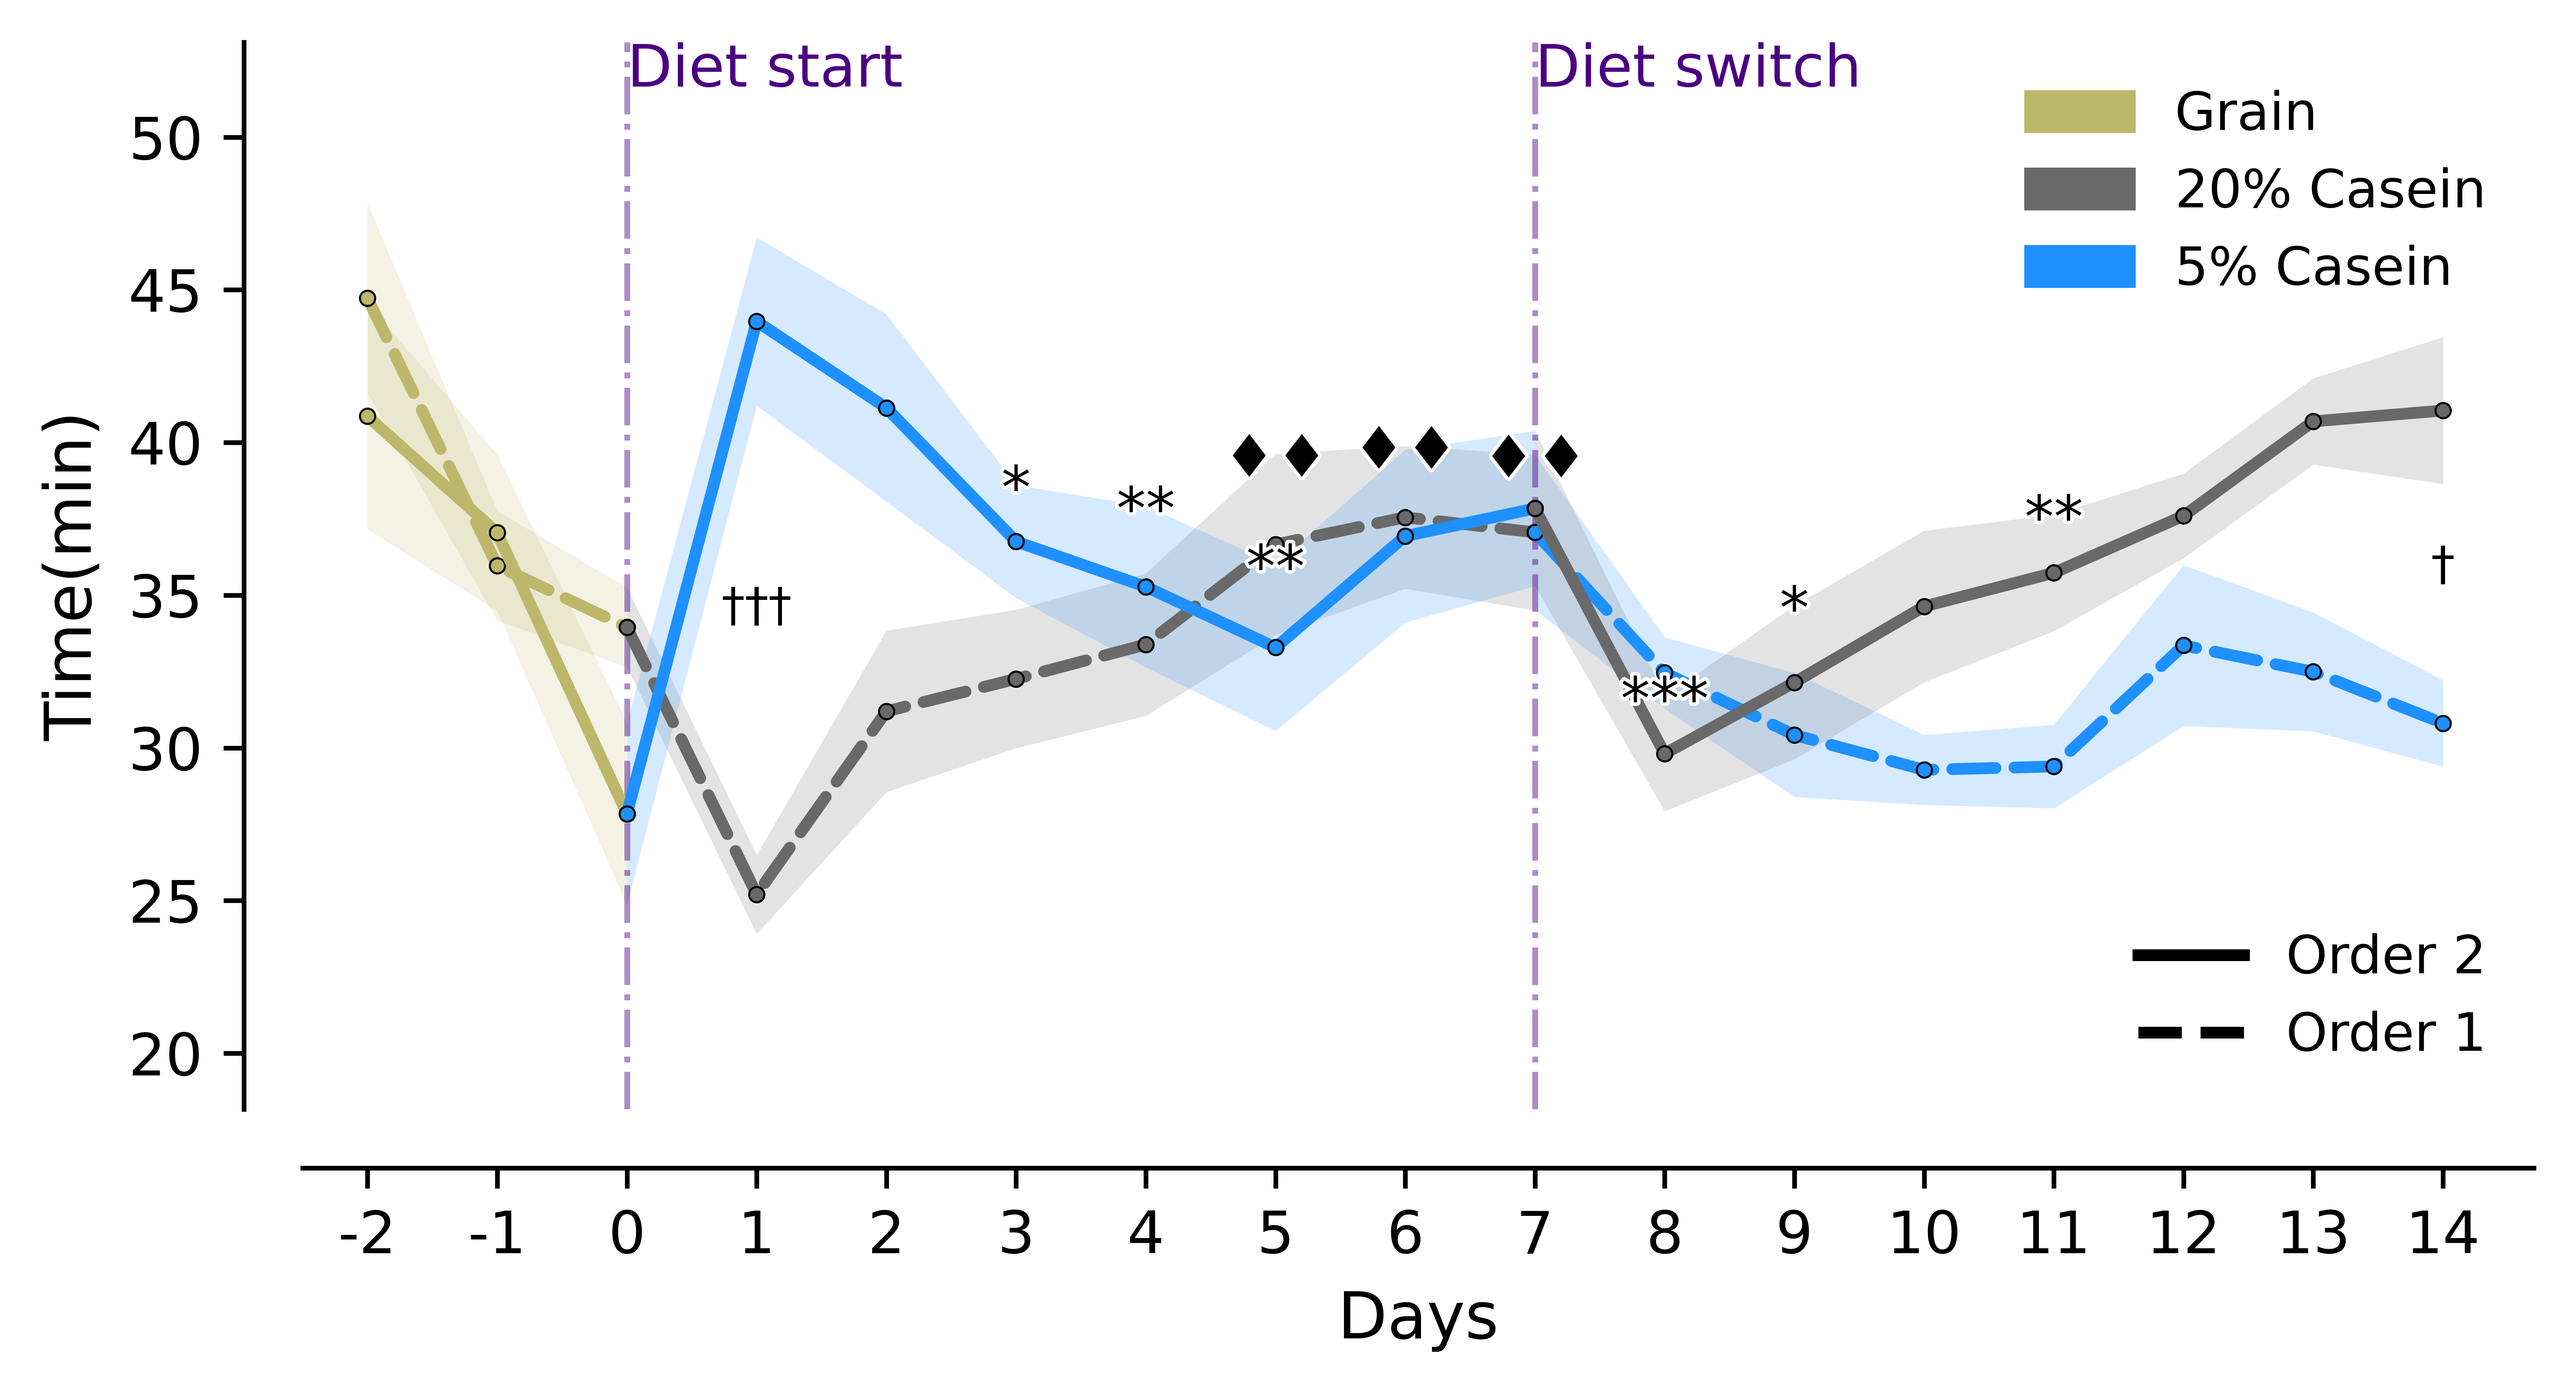

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation
from matplotlib import patheffects as pe
import os, re

# ======================== USER PATHS ========================
trend_path = '../results/INTERACTION_TIME/INTER_TIME.csv'

# Posthoc CSVs (Holm-corrected) for MEAL NUMBER
spec_dir = '../results/INTERACTION_TIME/RE_DO'
spec_PR0_vs_allO2    = os.path.join(spec_dir, 'SPEC_O2_PR0_vs_all_Order2_days.csv')       # stars (O2 PR0 vs all O2)
spec_O2PRk_vs_O1NRk  = os.path.join(spec_dir, 'SPEC_O2_PRk_vs_O1_NRk_matched_days.csv')   # daggers (PR block)
spec_O2NRk_vs_O1PRk  = os.path.join(spec_dir, 'SPEC_O2_NRk_vs_O1_PRk_matched_days.csv')   # daggers (NR block)
spec_O1NR0_vs_allO1  = os.path.join(spec_dir, 'SPEC_O1_NR0_vs_all_Order1_days.csv')       # diamonds (O1 NR0 vs all O1)

# ======================== DISPLAY / TOGGLES ========================
RELABEL_DAYS = True          # show -2,-1,0,1..14 on the x-axis
DRAW_CONNECTORS = False      # thin grey lines for daggers (between lines)
SHOW_PHASE_LINES = True
SAVE_PDF = True
PDF_PATH = "../plots/Fig.9B.pdf"

# Stat symbol placement controls
USE_SEM_ANCHOR = True        # place relative to mean±SEM (True) or mean (False)
SYMBOL_FONTSIZE = 10
STAR_SIDE = 'above'          # 'above' for O2
DIAMOND_SIDE = 'above'       # 'below' for O1
STAR_OFFSET_PTS = -6         # points; negative pulls closer to the line/SEM edge
DIAMOND_OFFSET_PTS = -6      # points; negative pulls closer to the line/SEM edge

# ======================== HELPERS ========================
def annotate_near_line(ax, xi, y, ysem=np.nan, text='', side='above', offset_pts=3, fs=10, use_sem=True):
    """
    Place `text` at x=xi, just above/below the line.
    - offset_pts is in *points* (try +/-3–6 for visible changes).
    - if use_sem=True, we sit on the mean±SEM edge; if False, we sit on the mean.
    """
    base = y
    if use_sem and np.isfinite(ysem):
        base = y + (ysem if side == 'above' else -ysem)

    sign = +1 if side == 'above' else -1
    trans = ax.transData + ScaledTranslation(0, sign * (offset_pts / 72.0), ax.figure.dpi_scale_trans)

    t = ax.text(
        xi, base, text,
        transform=trans,
        ha='center',
        va=('bottom' if side == 'above' else 'top'),
        fontsize=fs,
        zorder=7,
        clip_on=False,
        color='black'
    )
    t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

def mask_below_threshold(data, threshold=None):
    if threshold is None:
        return np.asarray(data, dtype=float)
    arr = np.asarray(data, dtype=float)
    return np.where(arr >= float(threshold), arr, np.nan)

def mean_sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    mean = np.nanmean(a, axis=axis)
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = std / np.sqrt(np.maximum(n, 1))
    sem[n <= 1] = np.nan
    return mean, sem

def line_kwargs(color, linestyle):
    return dict(
        color=color, linestyle=linestyle, linewidth=2,
        marker='o', markersize=2.6,
        markerfacecolor=color, markeredgecolor='black', markeredgewidth=0.35,
        solid_capstyle='round', dash_capstyle='round', zorder=3
    )

# X-index mapper
def x_idx(order, phase, day_int):
    # O1: G(0..2), NR(3..9), PR(10..16)
    # O2: G(0..2), PR(3..9), NR(10..16)
    if order == 1:
        base = 0 if phase=='G' else (3 if phase=='NR' else 10)
    else:
        base = 0 if phase=='G' else (3 if phase=='PR' else 10)
    return base + day_int

def pcol(df_):
    for c in df_.columns:
        cl = c.lower()
        if 'p' in cl and 'value' in cl:
            return c
    return df_.columns[-1]

PAT = re.compile(
    r'^(NR|PR)\s*X?(\d+)\s+Order\s*([12])\s*-\s*(NR|PR)\s*X?(\d+)\s+Order\s*([12])$',
    flags=re.IGNORECASE
)

def parse_contrast_label(lbl):
    m = PAT.match(lbl.strip())
    if not m:
        raise ValueError(f"Unparsable contrast label: {lbl}")
    phA, dA, oA, phB, dB, oB = m.groups()
    return (phA.upper(), int(dA), int(oA)), (phB.upper(), int(dB), int(oB))

def load_spec(path):
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)
    ccol = None
    for cand in ['contrast_pretty','contrast','label']:
        if cand in s.columns:
            ccol = cand; break
    if ccol is None:
        ccol = s.columns[0]
    s['_contrast_str'] = s[ccol].astype(str)
    s['_p'] = s[pcol(s)].astype(float)
    return s

def sym_for_p(p, scheme):
    if p >= 0.05: return ''
    if scheme == 'star':
        return '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    if scheme == 'dagger':
        return '†††' if p < 0.001 else ('††' if p < 0.01 else '†')
    if scheme == 'diamond':
        return '♦♦♦' if p < 0.001 else ('♦♦' if p < 0.01 else '♦')
    return ''

# ======================== LOAD MEANS ========================
df = pd.read_csv(trend_path)

grain_cols = ["G0", "G1", "G2"]
nr_cols    = ["NR0", "NR1", "NR2", "NR3", "NR4", "NR5", "NR6"]
pr_cols    = ["PR0", "PR1", "PR2", "PR3", "PR4", "PR5", "PR6"]

# Order 1: Grain -> NR -> PR
order_1_df = df[df["Order"] == 1]
order_1 = order_1_df[grain_cols + nr_cols + pr_cols].to_numpy(dtype=float)

# Order 2: Grain -> PR -> NR
order_2_df = df[df["Order"] == 2]
order_2 = order_2_df[grain_cols + pr_cols + nr_cols].to_numpy(dtype=float)

# For meals we typically don’t mask; set to a number if desired (e.g., 20)
threshold = None
order_1 = mask_below_threshold(order_1, threshold)
order_2 = mask_below_threshold(order_2, threshold)

o1_mean, o1_sem = mean_sem(order_1, axis=0)
o2_mean, o2_sem = mean_sem(order_2, axis=0)

# ======================== X-AXIS SEGMENTS ========================
x = np.arange(17)
x_grain = np.arange(0, 3)   # 0..2
x_mid   = np.arange(2, 10)  # 2..9
x_last  = np.arange(9, 17)  # 9..16

# ======================== COLOURS & LINES ========================
color_grain = "darkkhaki"
color_nr    = "dimgray"     # 20% Casein
color_pr    = "dodgerblue"  # 5% Casein

o1_colors = (color_grain, color_nr, color_pr)  # O1: G -> NR -> PR
o2_colors = (color_grain, color_pr, color_nr)  # O2: G -> PR -> NR

o1_ls = "--"  # dashed
o2_ls = "-"   # solid

# ======================== BUILD ANNOTATION MAPS ========================
PR0_any_O2 = {}   # stars: PR0 (O2) vs all O2 (PR1–6, NR0–6) -> above O2
O1_NR0_any = {}   # diamonds: NR0 (O1) vs all O1 (NR1–6, PR0–6) -> below O1
DAG_PR     = {}   # daggers: O2:PRk vs O1:NRk at x=3..9
DAG_NR     = {}   # daggers: O2:NRk vs O1:PRk at x=10..16

# A) PR0 vs ALL in Order 2 -> stars
df1 = load_spec(spec_PR0_vs_allO2)
if df1 is not None:
    for _, row in df1.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'star')
        if not s: 
            continue
        if oA==2 and phA=='PR' and dA==0 and oB==2 and phB in ['PR','NR']:
            PR0_any_O2[x_idx(2, phB, dB)] = s
        elif oB==2 and phB=='PR' and dB==0 and oA==2 and phA in ['PR','NR']:
            PR0_any_O2[x_idx(2, phA, dA)] = s

# B) NR0 (Order 1) vs ALL in Order 1 -> diamonds
dfB = load_spec(spec_O1NR0_vs_allO1)
if dfB is not None:
    for _, row in dfB.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'diamond')
        if not s:
            continue
        if oA==1 and phA=='NR' and dA==0 and oB==1 and phB in ['NR','PR']:
            if (phB=='NR' and dB in range(1,7)) or (phB=='PR' and dB in range(0,7)):
                O1_NR0_any[x_idx(1, phB, dB)] = s
        elif oB==1 and phB=='NR' and dB==0 and oA==1 and phA in ['NR','PR']:
            if (phA=='NR' and dA in range(1,7)) or (phA=='PR' and dA in range(0,7)):
                O1_NR0_any[x_idx(1, phA, dA)] = s

# C) Cross-order daggers
df3 = load_spec(spec_O2PRk_vs_O1NRk)
if df3 is not None:
    for _, row in df3.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='PR' and oA==2 and phB=='NR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_PR[x_idx(2,'PR',dA)] = s
        elif phB=='PR' and oB==2 and phA=='NR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_PR[x_idx(2,'PR',dB)] = s

df4 = load_spec(spec_O2NRk_vs_O1PRk)
if df4 is not None:
    for _, row in df4.iterrows():
        lbl = row['_contrast_str']; p = row['_p']
        try:
            (phA,dA,oA),(phB,dB,oB) = parse_contrast_label(lbl)
        except Exception:
            continue
        s = sym_for_p(p, 'dagger')
        if not s: continue
        if phA=='NR' and oA==2 and phB=='PR' and oB==1 and dA==dB and 0<=dA<=6:
            DAG_NR[x_idx(2,'NR',dA)] = s
        elif phB=='NR' and oB==2 and phA=='PR' and oA==1 and dA==dB and 0<=dB<=6:
            DAG_NR[x_idx(2,'NR',dB)] = s

# ======================== PLOT ========================
fig, ax = plt.subplots(figsize=(6.2, 3.4), dpi=1200)

# Order 1 (G, NR, PR)
ax.plot(x_grain, o1_mean[x_grain], **line_kwargs(o1_colors[0], o1_ls))
ax.fill_between(x_grain, o1_mean[x_grain]-o1_sem[x_grain], o1_mean[x_grain]+o1_sem[x_grain],
                color=o1_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o1_mean[x_mid],   **line_kwargs(o1_colors[1], o1_ls))
ax.fill_between(x_mid, o1_mean[x_mid]-o1_sem[x_mid], o1_mean[x_mid]+o1_sem[x_mid],
                color=o1_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o1_mean[x_last],  **line_kwargs(o1_colors[2], o1_ls))
ax.fill_between(x_last, o1_mean[x_last]-o1_sem[x_last], o1_mean[x_last]+o1_sem[x_last],
                color=o1_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Order 2 (G, PR, NR)
ax.plot(x_grain, o2_mean[x_grain], **line_kwargs(o2_colors[0], o2_ls))
ax.fill_between(x_grain, o2_mean[x_grain]-o2_sem[x_grain], o2_mean[x_grain]+o2_sem[x_grain],
                color=o2_colors[0], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_mid,   o2_mean[x_mid],   **line_kwargs(o2_colors[1], o2_ls))
ax.fill_between(x_mid, o2_mean[x_mid]-o2_sem[x_mid], o2_mean[x_mid]+o2_sem[x_mid],
                color=o2_colors[1], alpha=0.18, linewidth=0, zorder=1)
ax.plot(x_last,  o2_mean[x_last],  **line_kwargs(o2_colors[2], o2_ls))
ax.fill_between(x_last, o2_mean[x_last]-o2_sem[x_last], o2_mean[x_last]+o2_sem[x_last],
                color=o2_colors[2], alpha=0.18, linewidth=0, zorder=1)

# Phase dividers + labels
if SHOW_PHASE_LINES:
    ax.axvline(2, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)
    ax.axvline(9, linestyle="-.", color="indigo", alpha=0.45, linewidth=1)

# Y range with extra bottom headroom for diamonds
y_top = np.nanmax([np.nanmax(o1_mean + o1_sem), np.nanmax(o2_mean + o2_sem)])
y_bot = np.nanmin([np.nanmin(o1_mean - o1_sem), np.nanmin(o2_mean - o2_sem)])
yrange = (y_top - y_bot) if np.isfinite(y_top - y_bot) else 1.0
ax.set_ylim(y_bot - 0.24*yrange, y_top + 0.22*yrange)

# Labels on phase lines
ax.text(2, y_bot + 1.22*yrange, "Diet start",  ha='left', va='top', fontsize=10, color="indigo")
ax.text(9, y_bot + 1.22*yrange, "Diet switch", ha='left', va='top', fontsize=10, color="indigo")

# X axis
ax.set_xlim(-0.5, 16.7)
ax.set_xticks(np.arange(17))
if RELABEL_DAYS:
    ax.set_xticklabels([str(i - 2) for i in range(17)])
ax.set_xlabel("Days", fontsize=11)
ax.set_ylabel("Time(min)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))
ax.grid(False)

# Diet legend
Grain_patch = mpatches.Patch(color=color_grain, label='Grain')
NR_patch    = mpatches.Patch(color=color_nr,    label='20% Casein')
PR_patch    = mpatches.Patch(color=color_pr,    label='5% Casein')
leg1 = ax.legend(handles=[Grain_patch, NR_patch, PR_patch],
                 loc='upper right', frameon=False, fontsize=9)

# Order legend
order_handles = [
    Line2D([0], [0], color='black', linestyle=o2_ls, linewidth=2, label='Order 2'),
    Line2D([0], [0], color='black', linestyle=o1_ls, linewidth=2, label='Order 1'),
]
leg2 = ax.legend(handles=order_handles, loc='lower right', frameon=False, fontsize=9)
ax.add_artist(leg1)

# ======================== ANNOTATIONS ========================
def y_at(order, xi):
    return (o1_mean[xi], o1_sem[xi]) if order==1 else (o2_mean[xi], o2_sem[xi])

# Asterisks (PR0 vs all in O2) -> ABOVE Order 2 line, adjustable offset
for xi, st in PR0_any_O2.items():
    if not st: 
        continue
    y2, y2s = y_at(2, xi)
    if np.isfinite(y2):
        annotate_near_line(
            ax, xi, y2, y2s, st,
            side=STAR_SIDE, offset_pts=STAR_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Diamonds (NR0 O1 vs all O1) -> BELOW Order 1 line, adjustable offset
for xi, dm in O1_NR0_any.items():
    if not dm: 
        continue
    y1, y1s = y_at(1, xi)
    if np.isfinite(y1):
        annotate_near_line(
            ax, xi, y1, y1s, dm,
            side=DIAMOND_SIDE, offset_pts=DIAMOND_OFFSET_PTS,
            fs=SYMBOL_FONTSIZE, use_sem=USE_SEM_ANCHOR
        )

# Daggers (cross-order) BETWEEN lines (unchanged placement)
for bucket in (DAG_PR, DAG_NR):
    for xi, dg in bucket.items():
        y1, _ = y_at(1, xi)
        y2, _ = y_at(2, xi)
        if np.isfinite(y1) and np.isfinite(y2):
            ylo, yhi = min(y1, y2), max(y1, y2)
            if DRAW_CONNECTORS and (yhi - ylo) > 0:
                ax.plot([xi, xi], [ylo + 0.01*yrange, yhi - 0.01*yrange],
                        color='gray', linewidth=0.6, alpha=0.5, zorder=6)
            t = ax.text(xi, (ylo + yhi)/2.0, dg, ha='center', va='center',
                        fontsize=SYMBOL_FONTSIZE-2, color='black', zorder=7)
            t.set_path_effects([pe.withStroke(linewidth=1.2, foreground='white')])

plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.02)
plt.show()
